In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
#run from repo root...
os.chdir(r"C:/Users/jamed\Documents/repos/terrain_classification_project/TerrainClassificationForFloodModelling")

In [3]:
from structured_data_utils.data import ModelData
from structured_data_utils.structured_data_interfacing import standardise_dataset


In [4]:
standardise_dataset("WILLOWAN", force=True)

In [5]:
willowan_data = ModelData()
willowan_data.prepare_data("WILLOWAN", sliding_window_size=200, stride=20)

pad_x: 1320, pad_y: 1028
1257.0
[local_normalise:input] shape=(1, 2135, 2610) dtype=torch.float32 total=5572350 valid=5033127 nan%=9.68
[local_normalise:input] min=113.168098 max=128.880936 mean=124.579155 std=1.396130 median=124.953583 p01=118.729362 p05=121.867531 p95=125.641922 p99=125.835381
[local_normalise:output] shape=(1, 2135, 2610) dtype=torch.float32 total=5572350 valid=5572350 nan%=0.00
[local_normalise:output] min=0.000000 max=31.472307 mean=16.033527 std=1.000000 median=16.033672 p01=12.511988 p05=15.364855 p95=16.741085 p99=19.478558


TypeError: get_segments_with_sliding_window() got an unexpected keyword argument 'apply_rotation'

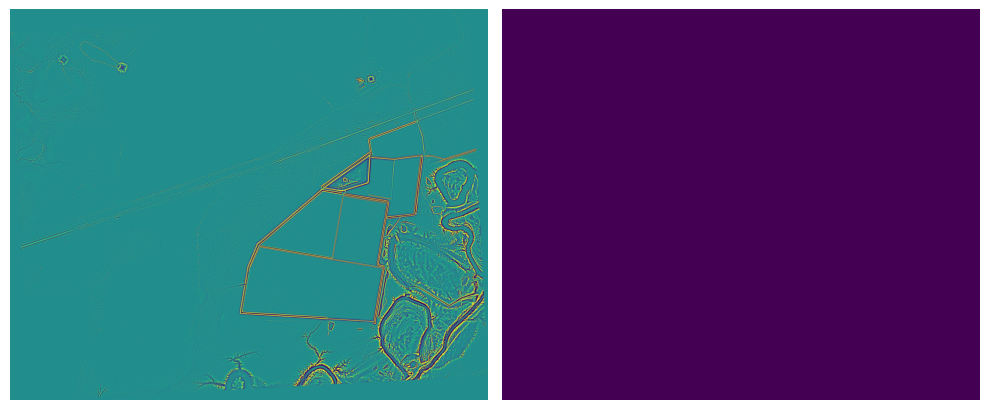

In [ ]:
from model_prototyping.unet_implementation.metrics import show_matrices
show_matrices([willowan_data.data_with_labels.data[0], willowan_data.data_with_labels.labels[0]])

In [ ]:
standardise_dataset("WILLOWAN", force=True)

In [ ]:
#beermery_data = ModelData()
#beermery_data.prepare_data("BEERMERY", sliding_window_size=300, stride=200)

In [ ]:
from model_prototyping.unet_implementation.metrics import show_matrices
#show_matrices([beermery_data.data_with_labels.data[0], beermery_data.data_with_labels.labels[0]])

In [ ]:
#combined_data = ModelData.splice_model_data([beermery_data, willowan_data])

In [ ]:
from model_prototyping.unet_implementation.modules import train_model, test_model_visual


In [ ]:
from model_prototyping.unet_implementation.constants import (
    UNET_BLOCK_BASELINE,
    UNET_BLOCK_PREACT,
    UNET_BLOCK_DROPOUT,
    UNET_BLOCK_DILATED,
    UNET_BLOCK_RESIDUAL,
)


In [ ]:
willowan_data.data_with_labels.data.shape

torch.Size([1, 2135, 2610])

Epoch 50/1000 - loss: 0.3357
lr: 0.000488126013940816


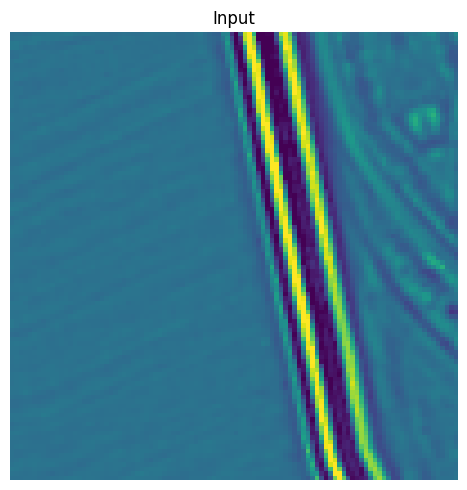

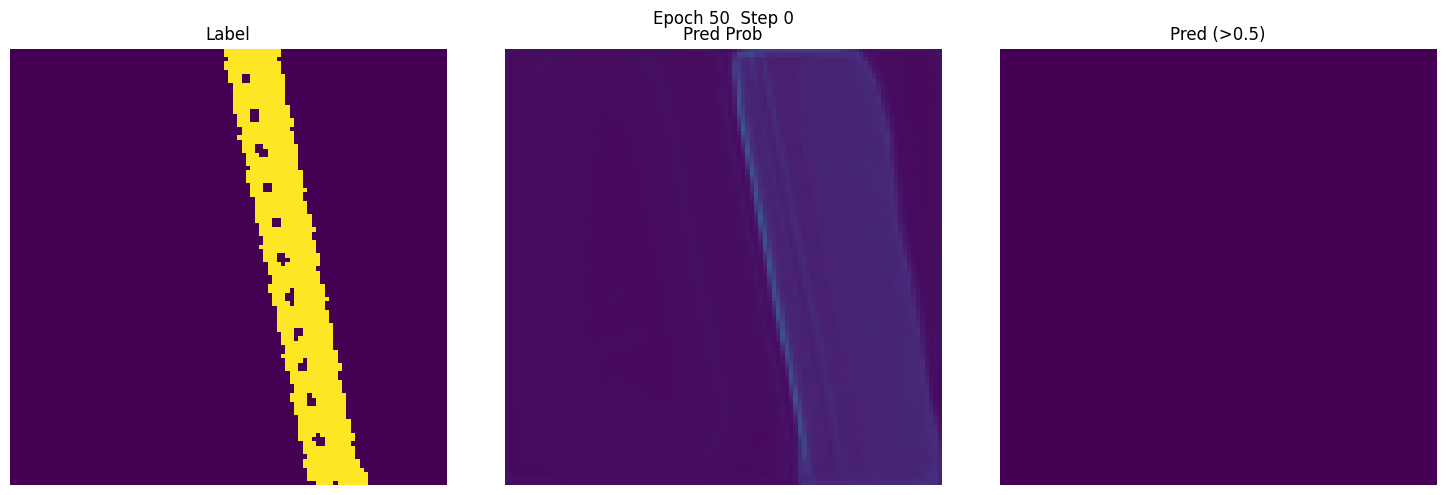

Epoch 100/1000 - loss: 0.0511
lr: 0.00045329747873729034


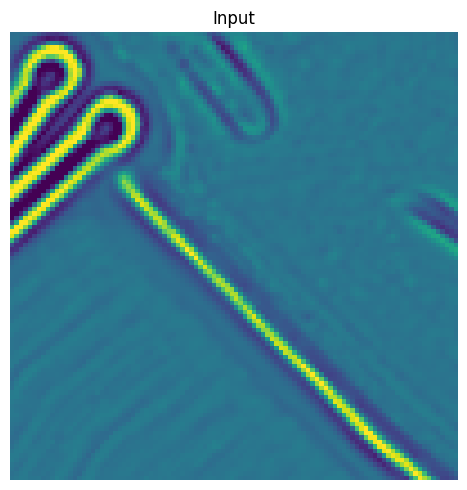

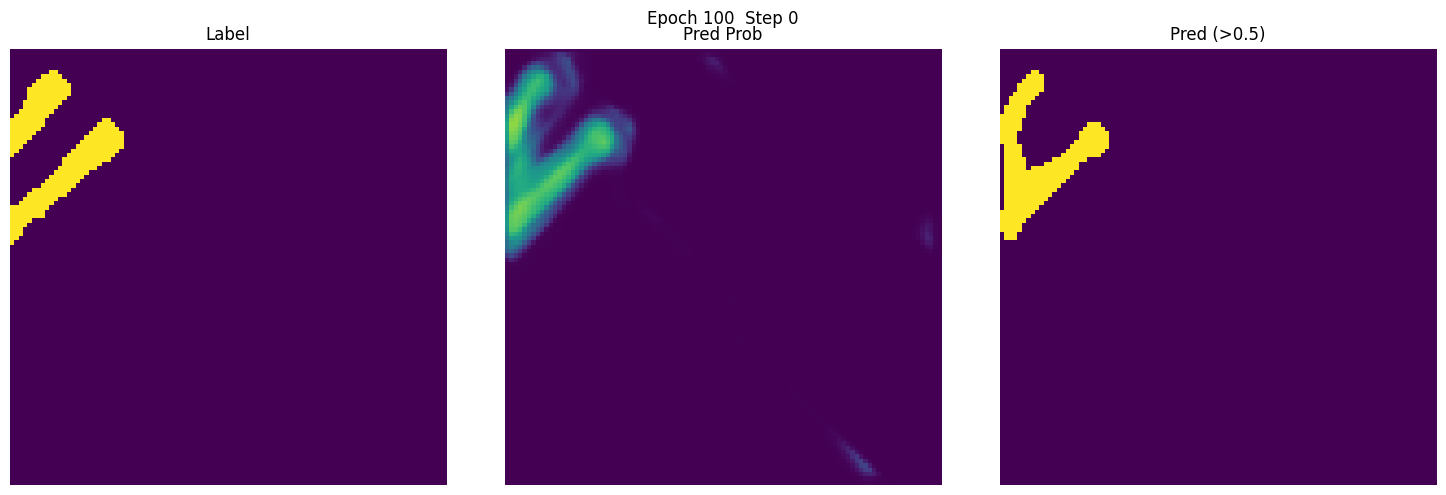

Epoch 150/1000 - loss: 0.0649
lr: 0.0004004238426477074


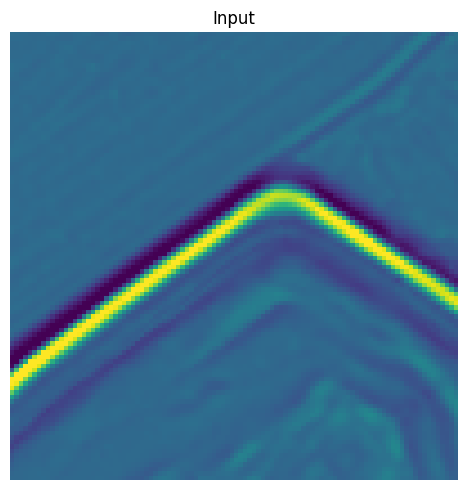

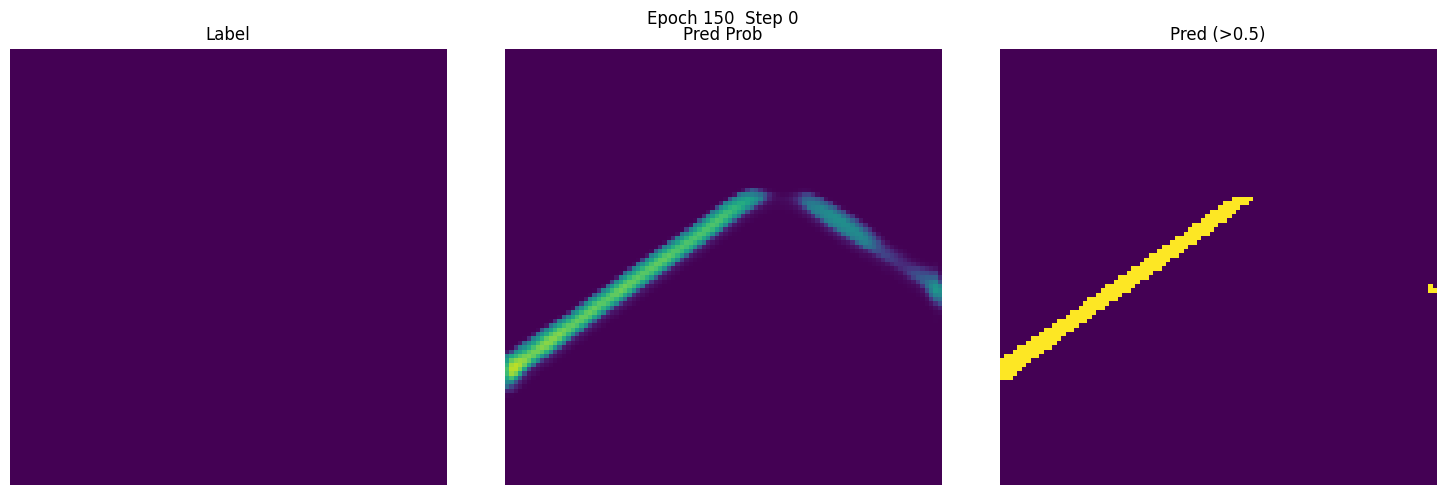

Epoch 200/1000 - loss: 0.0000
lr: 0.00033646649945963847


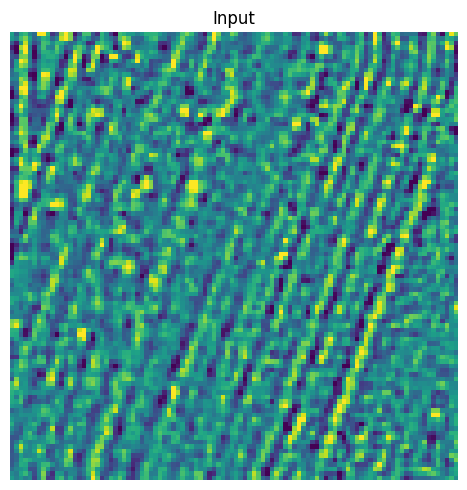

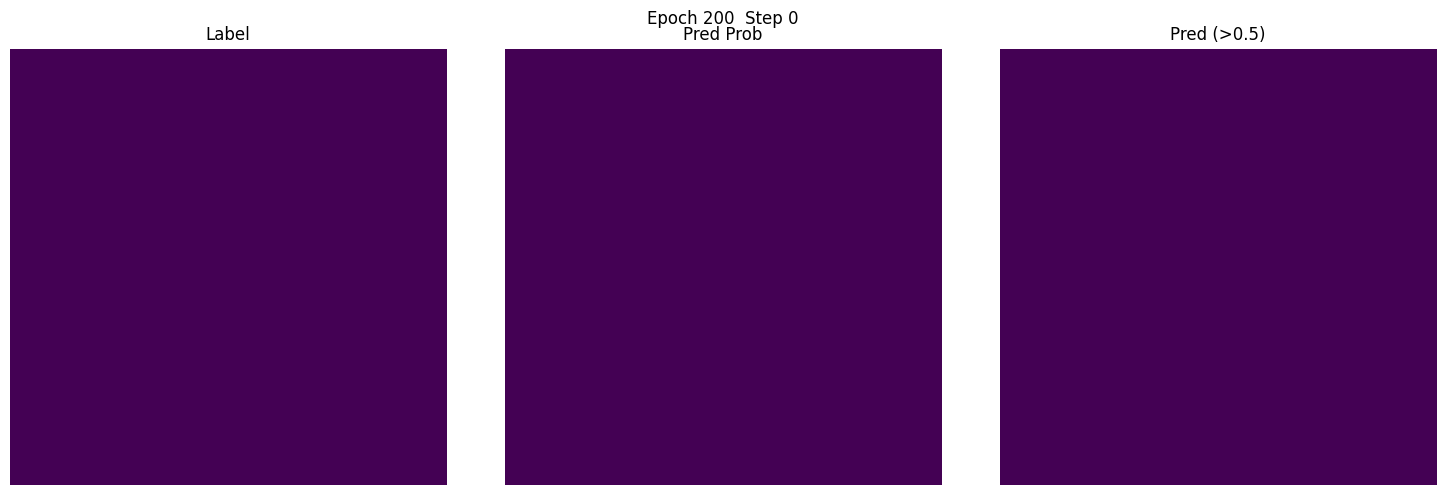

Epoch 250/1000 - loss: 0.1563
lr: 0.0002698739593129587


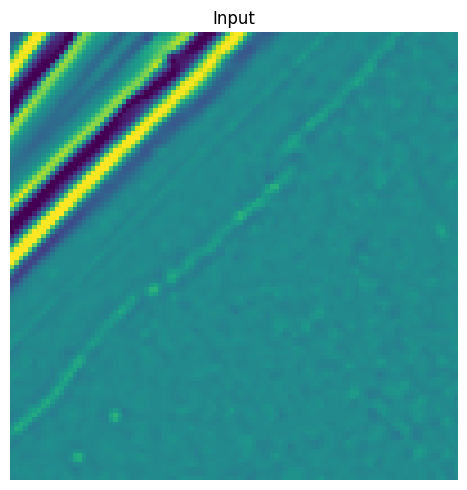

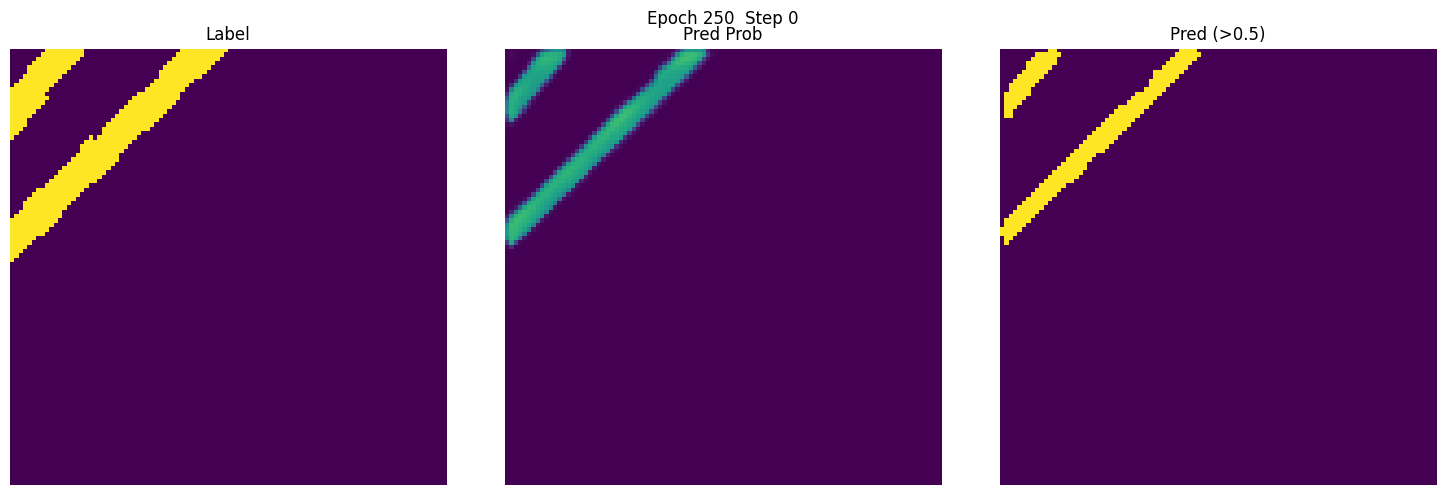

Epoch 300/1000 - loss: 0.0705
lr: 0.00020533237869729232


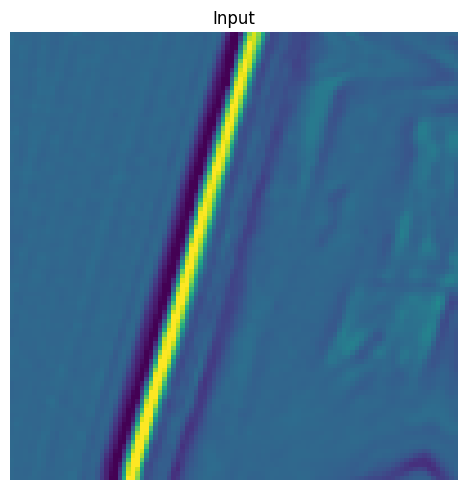

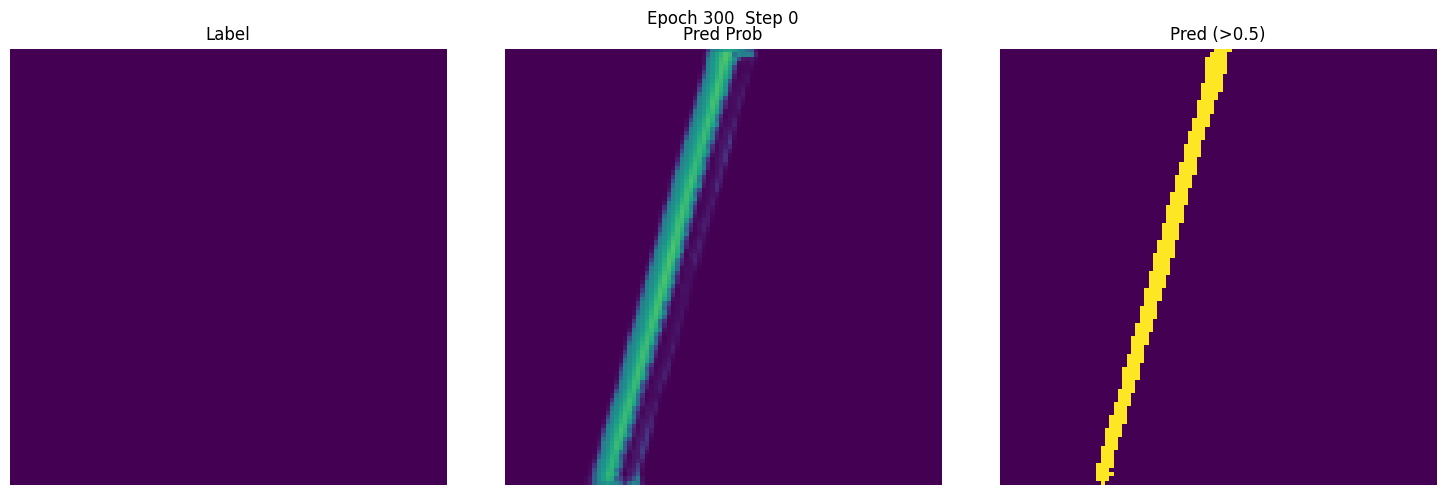

Epoch 350/1000 - loss: 0.0317
lr: 0.00014860696728882466


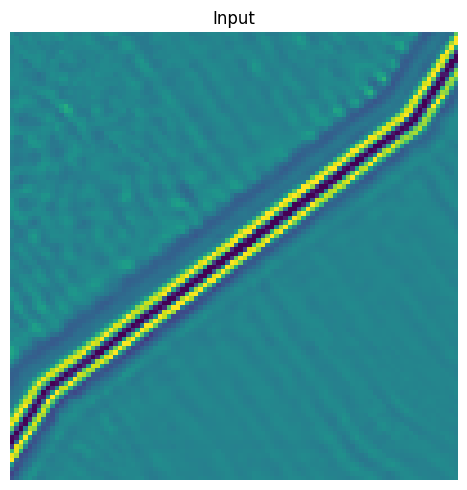

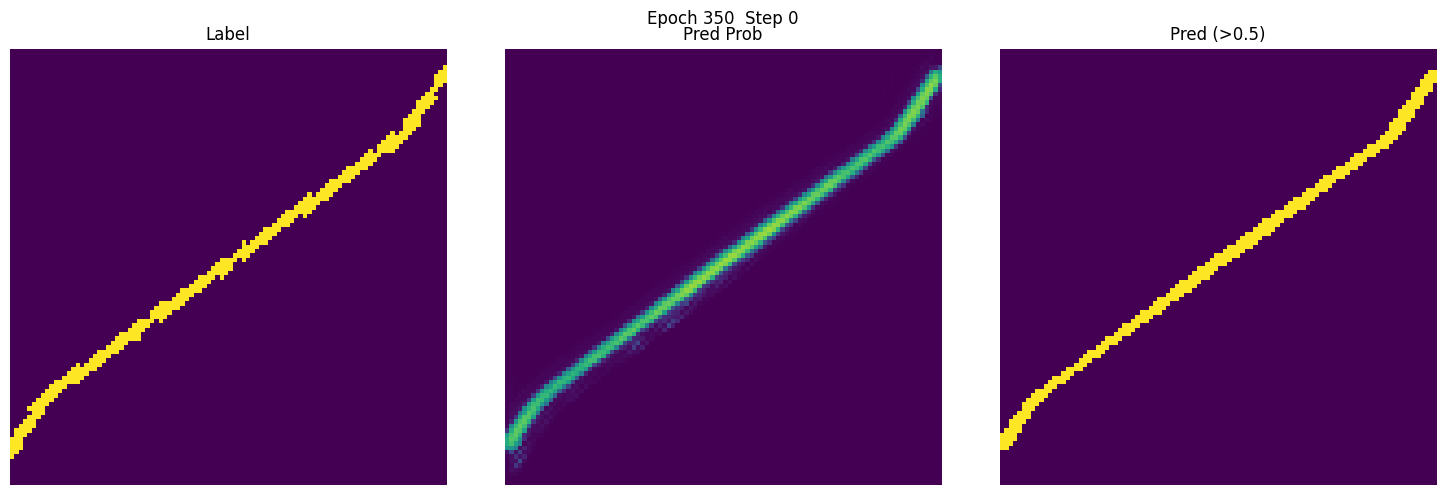

Epoch 400/1000 - loss: 0.8677
lr: 0.00010230719551050375


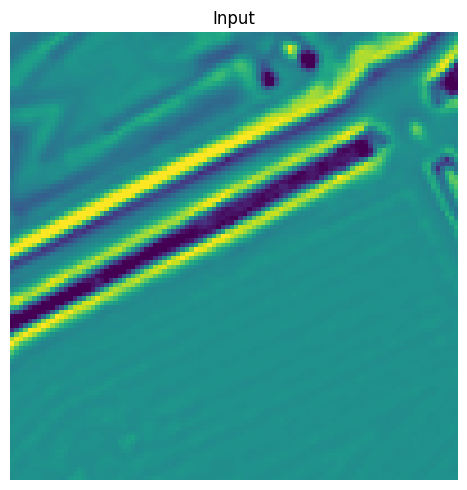

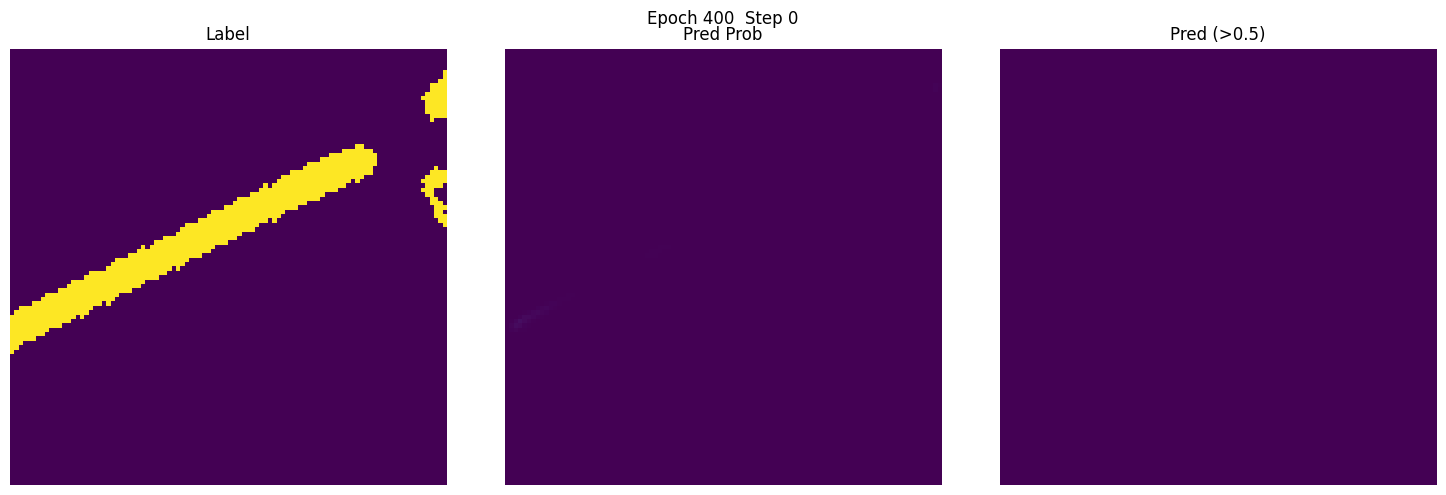

Epoch 450/1000 - loss: 0.0000
lr: 6.699747934720949e-05


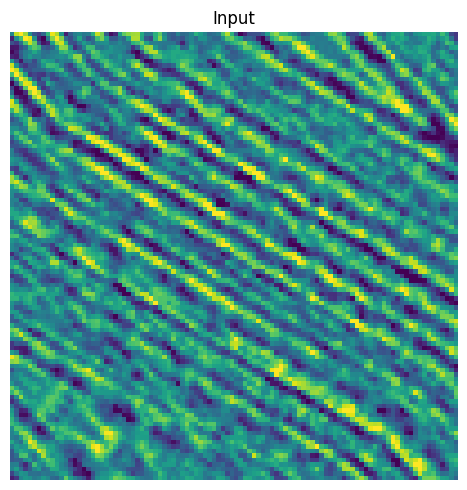

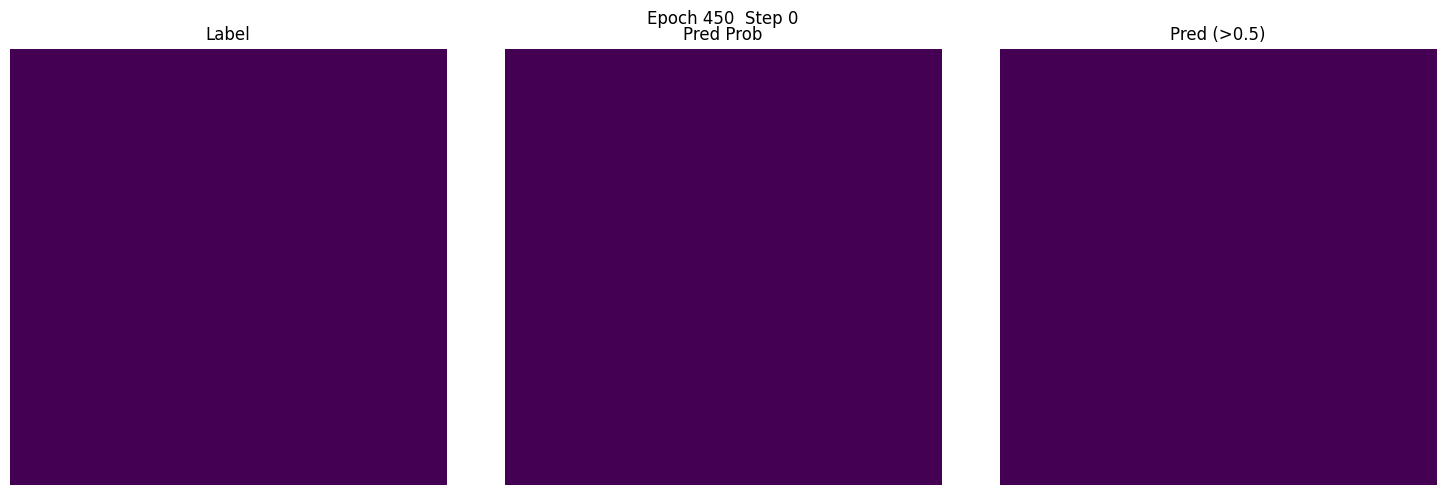

Epoch 500/1000 - loss: 0.8619
lr: 4.173457762672698e-05


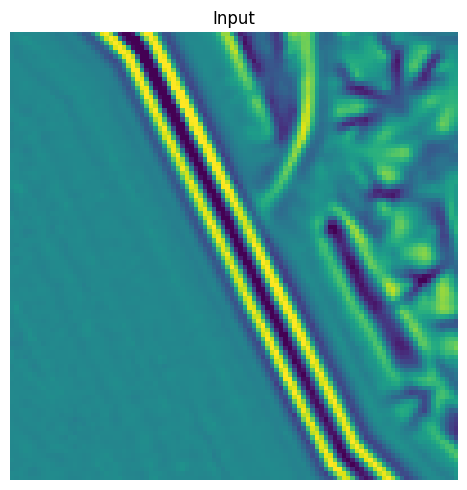

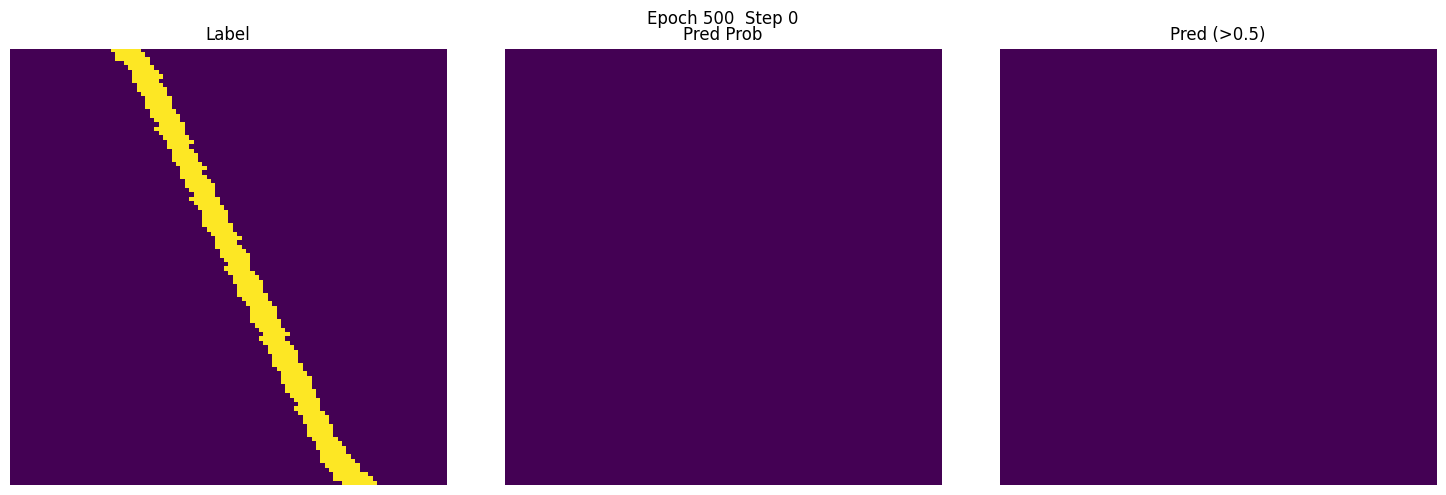

Epoch 550/1000 - loss: 0.0178
lr: 2.4729700520730053e-05


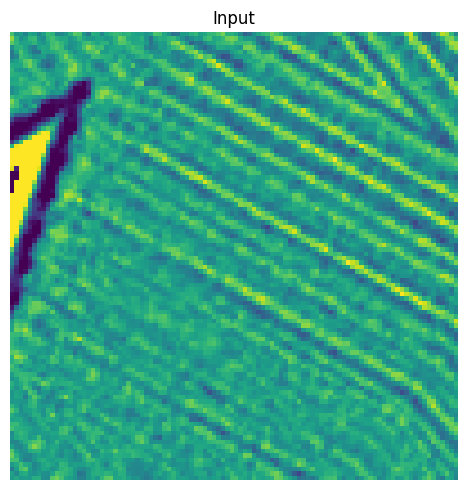

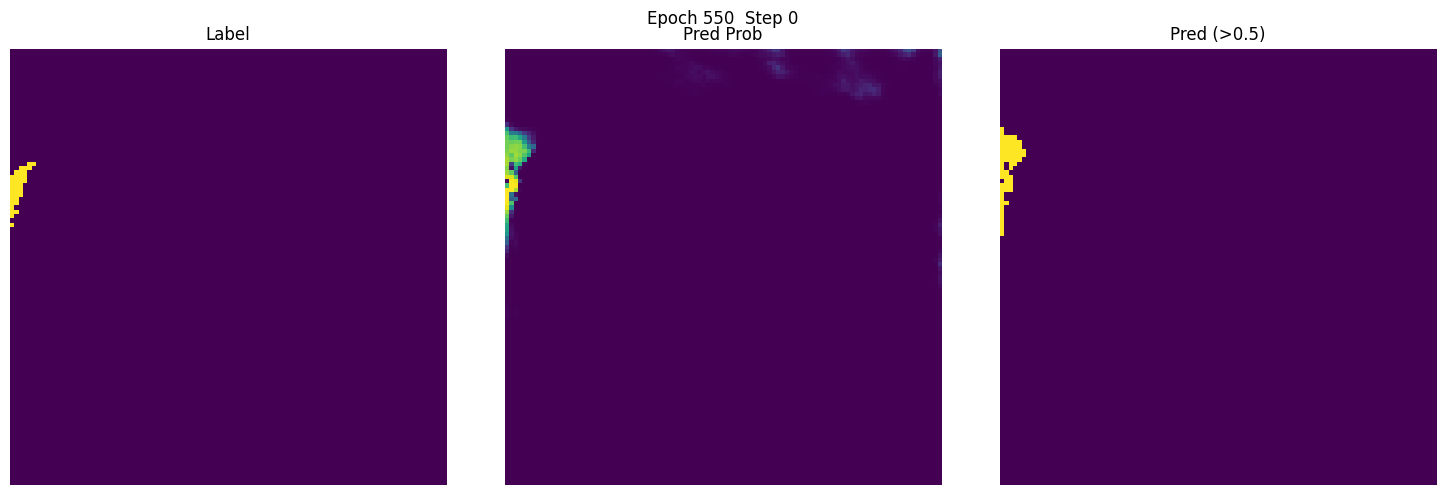

Epoch 600/1000 - loss: 0.0000
lr: 1.3938850715308576e-05


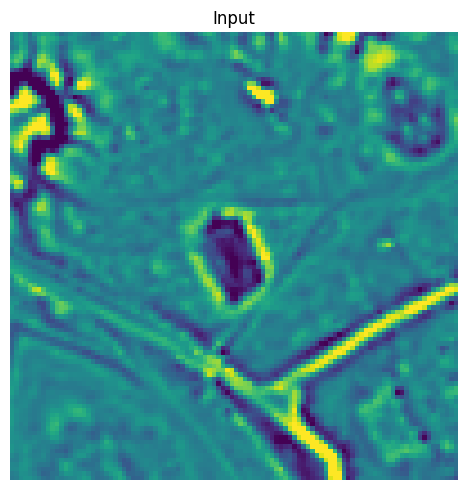

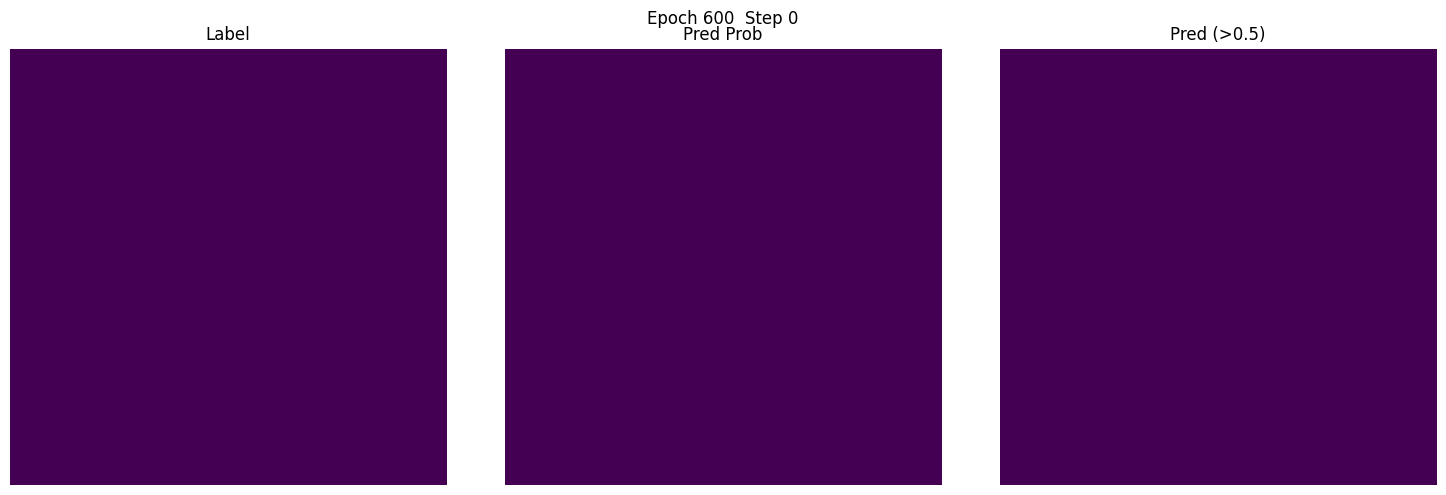

Epoch 650/1000 - loss: 0.0000
lr: 7.473436555059623e-06


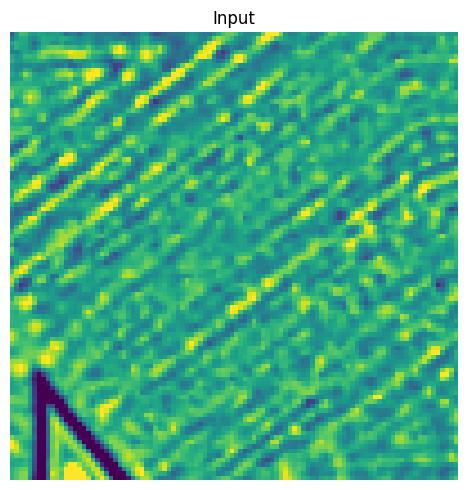

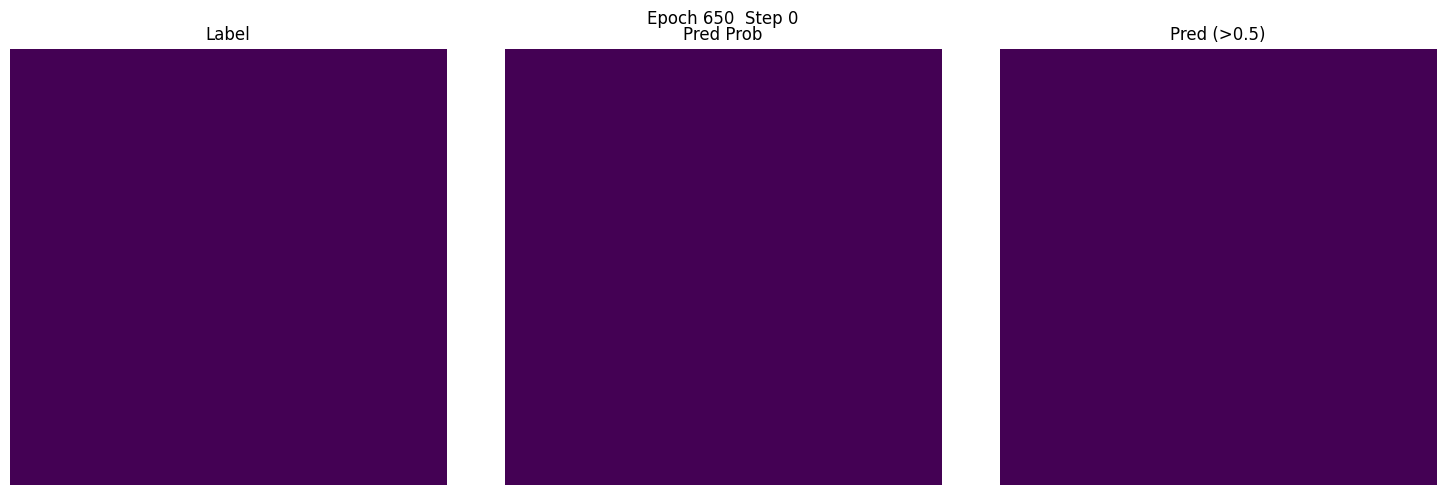

Epoch 700/1000 - loss: 0.0583
lr: 3.8115271044895324e-06


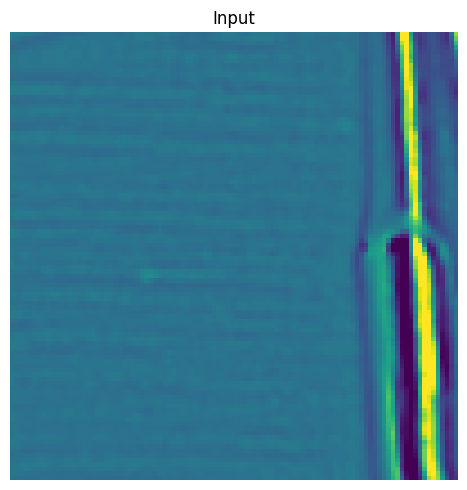

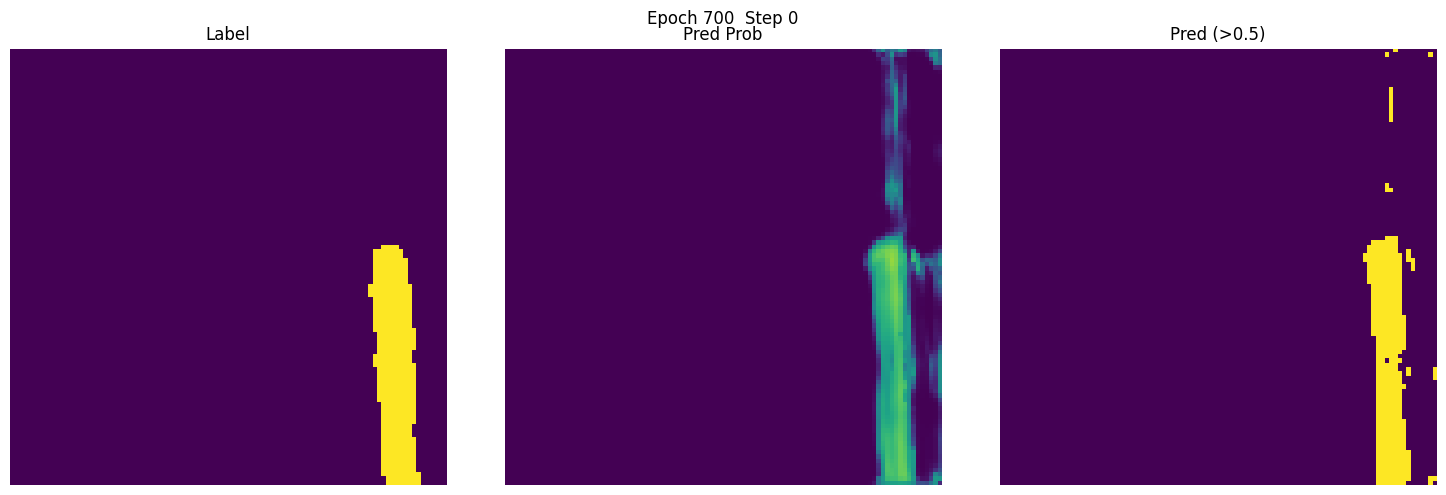

Epoch 750/1000 - loss: 0.0557
lr: 1.8491108559578006e-06


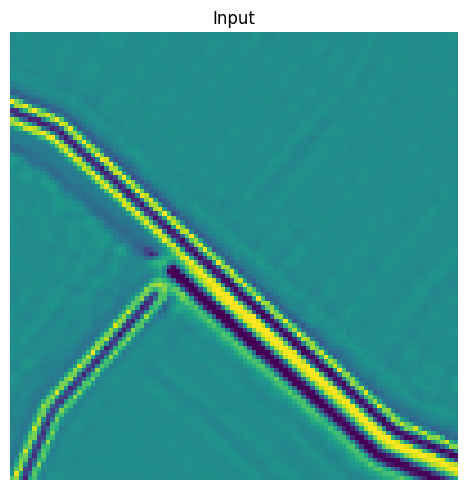

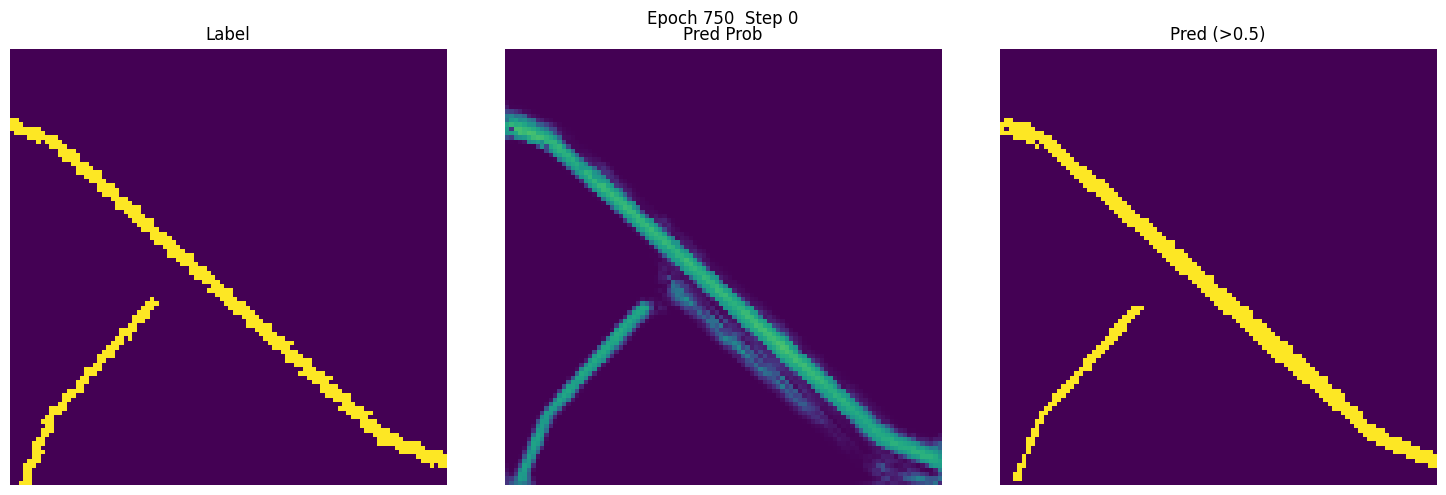

Epoch 800/1000 - loss: 0.1366
lr: 8.533204613638518e-07


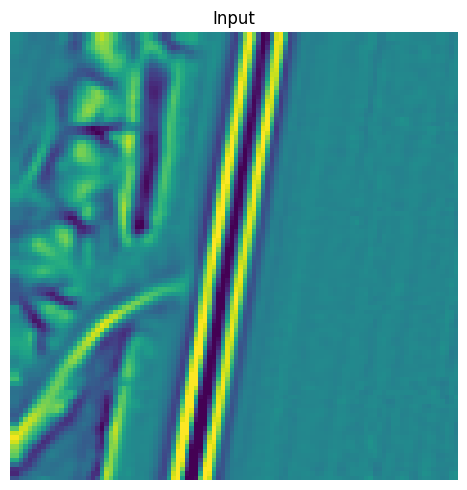

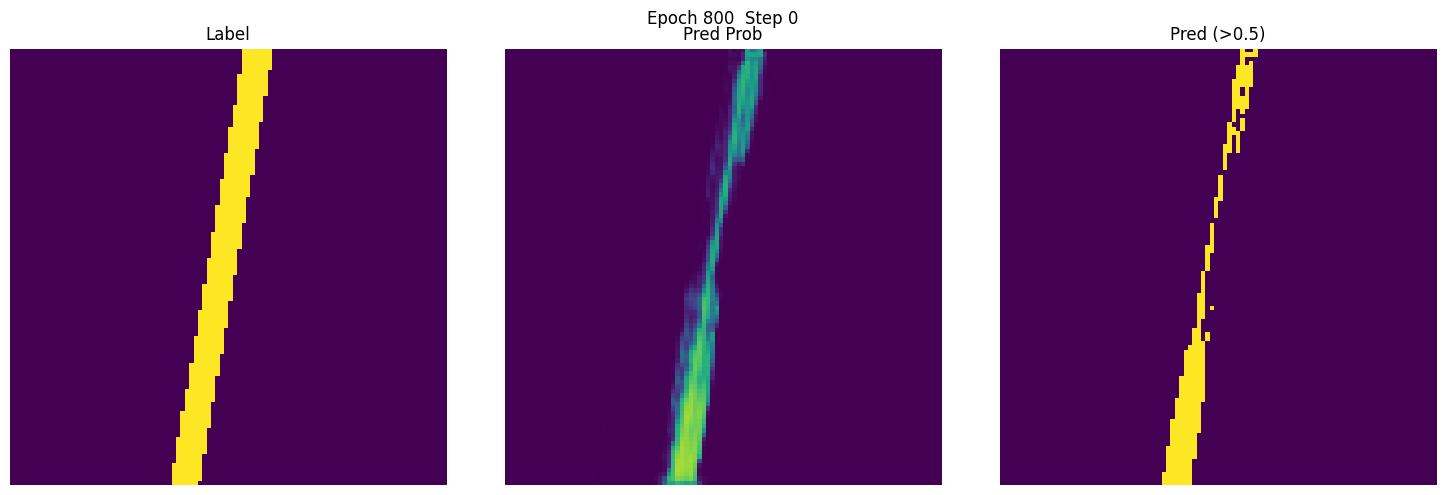

Epoch 850/1000 - loss: 0.0000
lr: 3.7969828239220014e-07


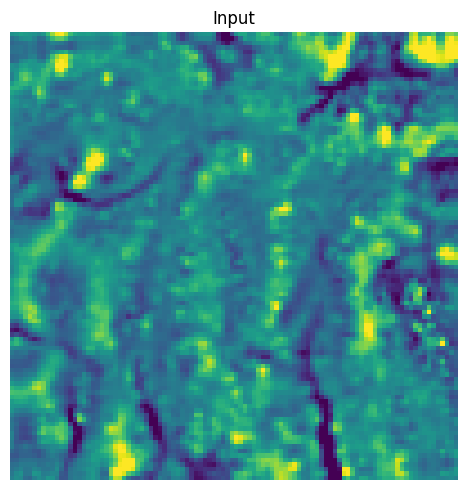

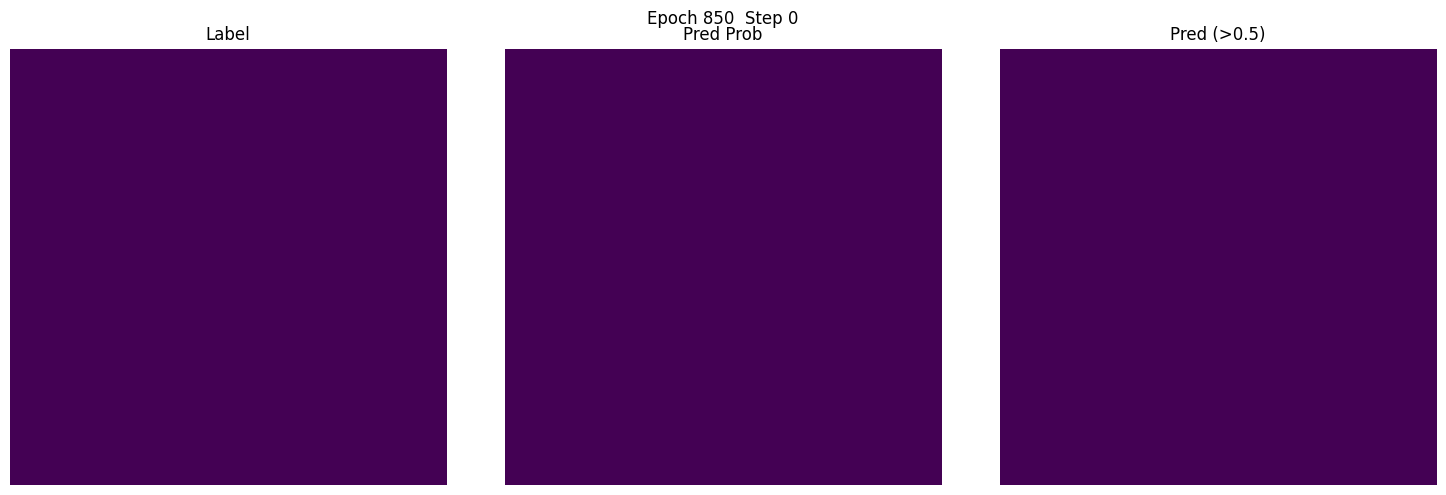

Epoch 900/1000 - loss: 0.1187
lr: 1.5867402194945776e-07


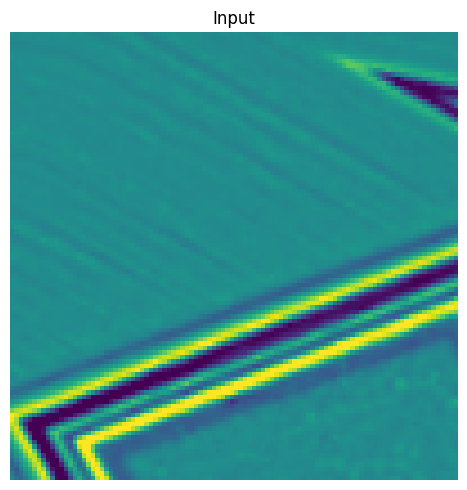

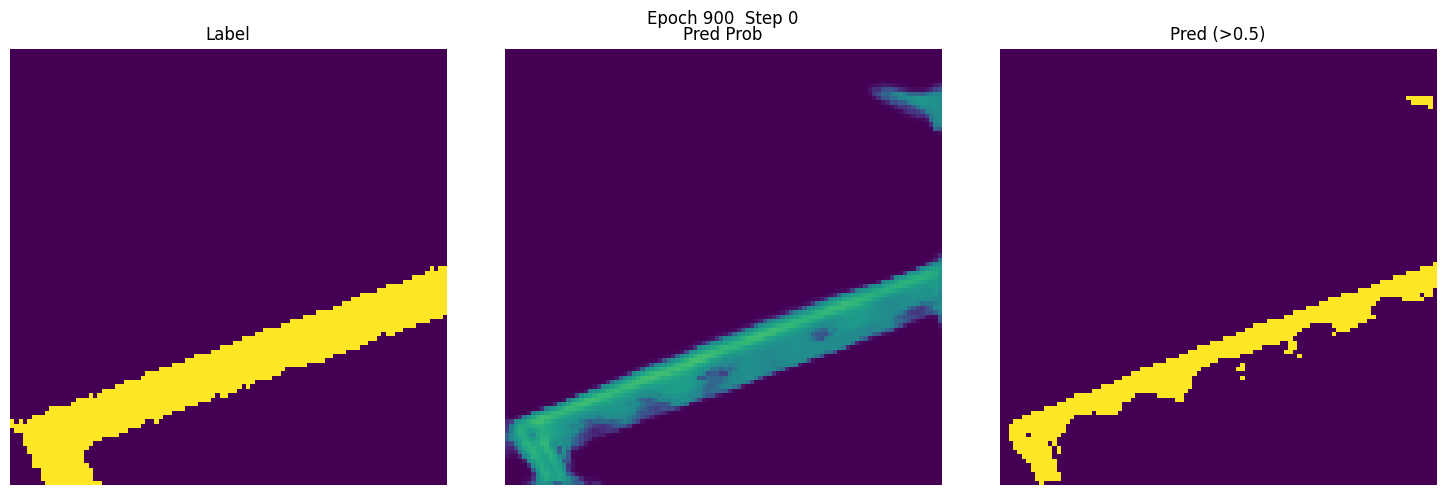

Epoch 950/1000 - loss: 0.0440
lr: 6.307515158103209e-08


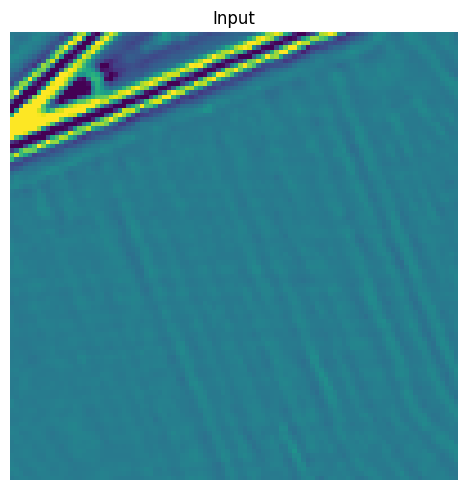

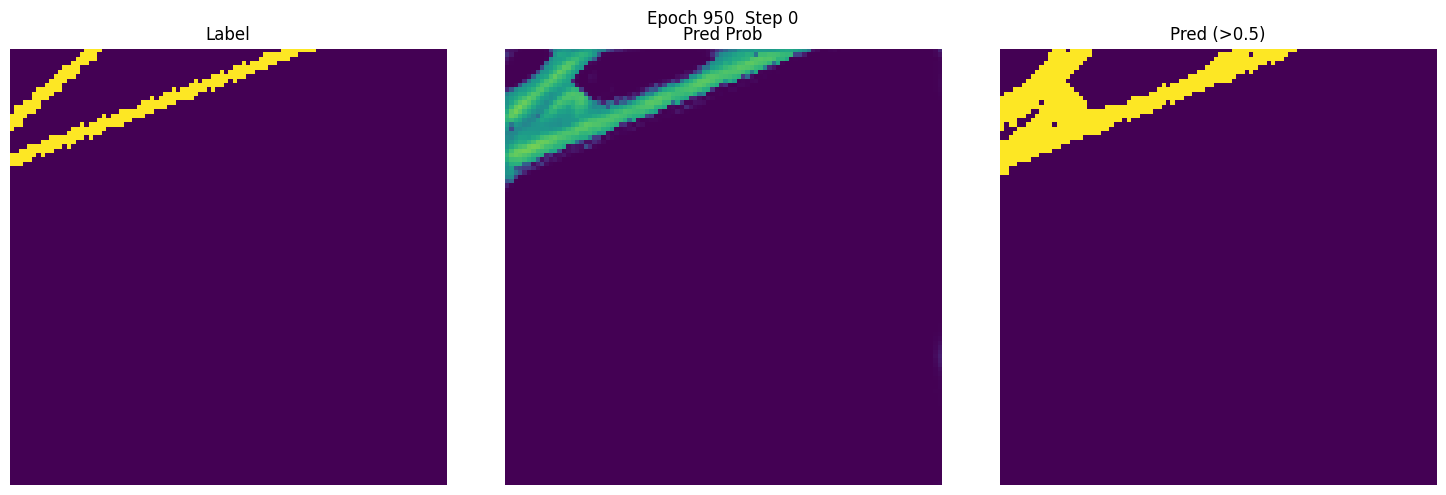

Epoch 1000/1000 - loss: 0.0000
lr: 2.3850421087299775e-08


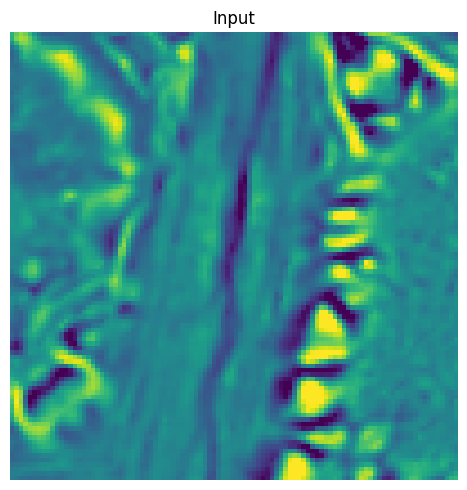

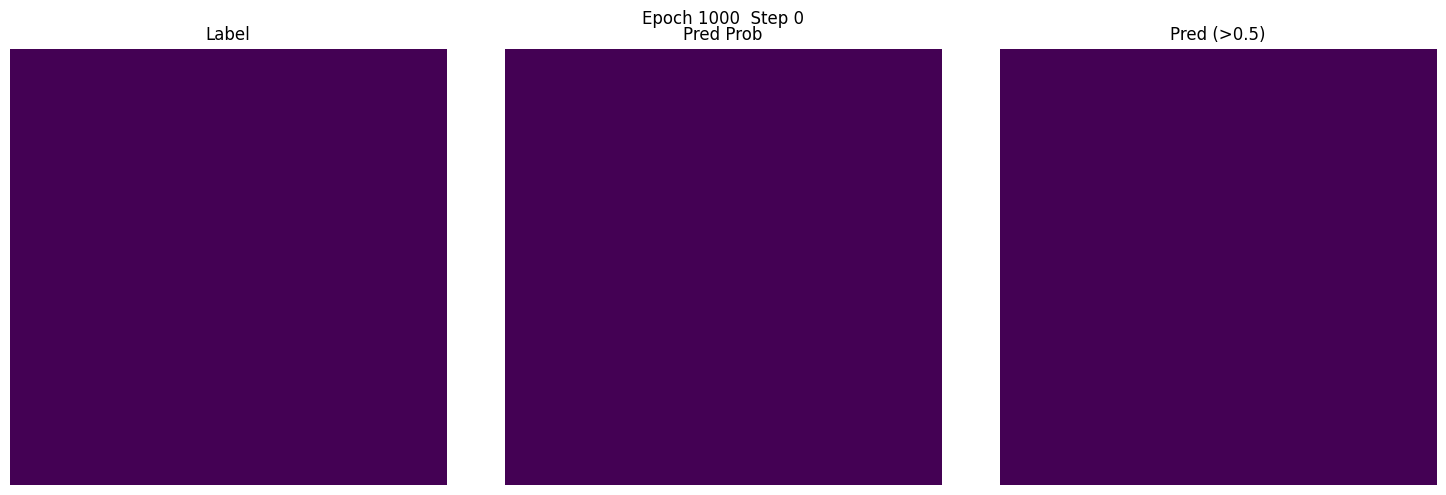


Training Complete!


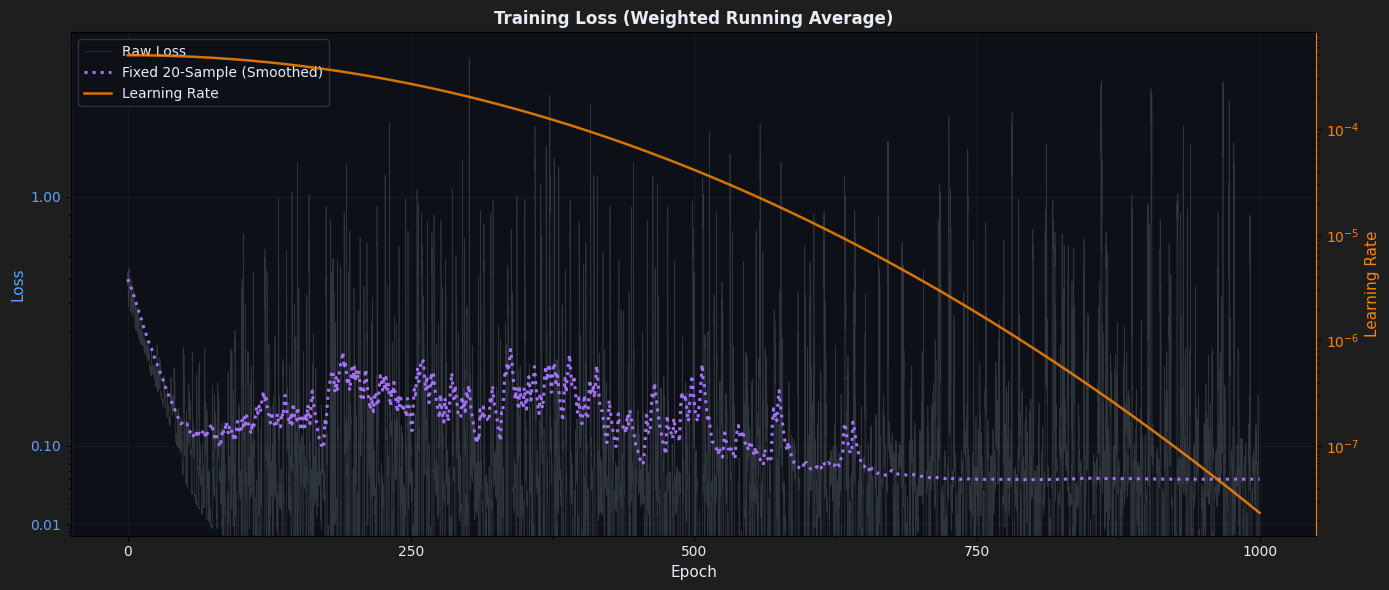


Loss Statistics:
  Final Fixed Sample Loss: 0.050078
  Initial loss: 0.629120
  Final loss: 0.015633
  Min loss: 0.000001
  Max loss: 1.912667
  Final smooth average: 0.058089
  Final responsive average: 0.028675
  Total steps: 19970


In [ ]:
# Residual connections (skip connections within block)
model_residual = train_model(willowan_data,
                    num_epochs=1000,
                    viz_every=50,
                    features=[8,16,32],
                    lr=5e-4,
                    lr_decay=0.99999995,
                    pos_bias=1,
                    block_config=UNET_BLOCK_RESIDUAL,)


Epoch 200/2500 - loss: 0.0113
lr: 0.002018798996757834


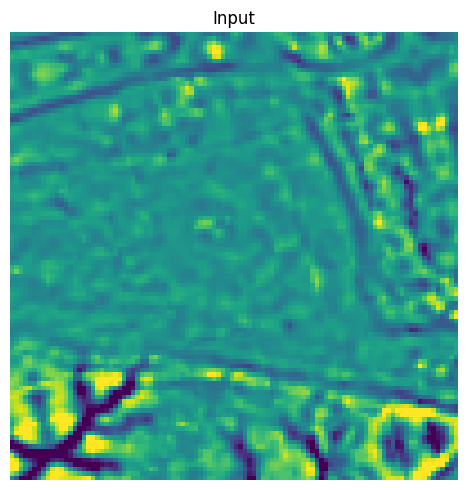

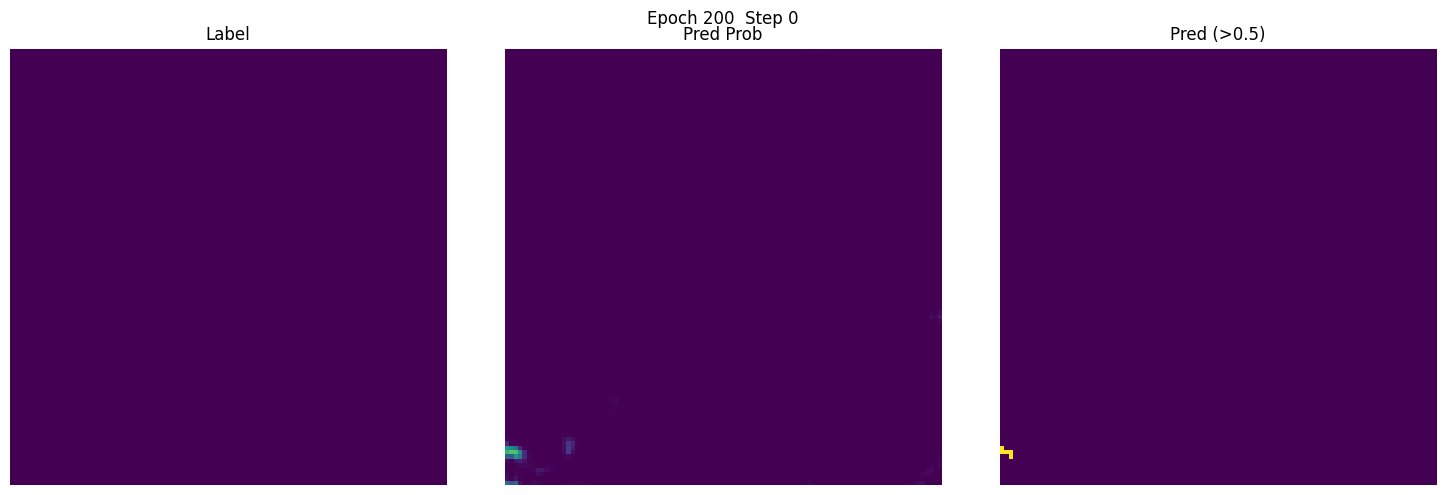

Epoch 400/2500 - loss: 0.1065
lr: 0.0006104265816340661


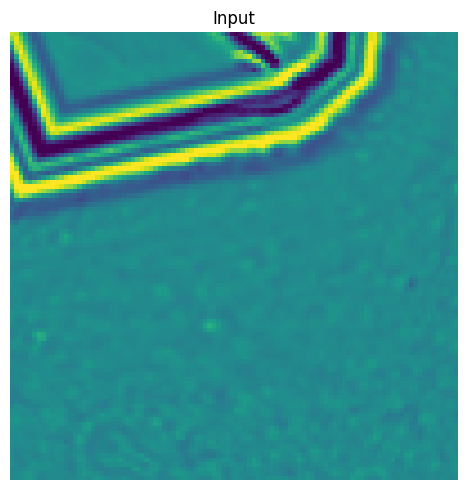

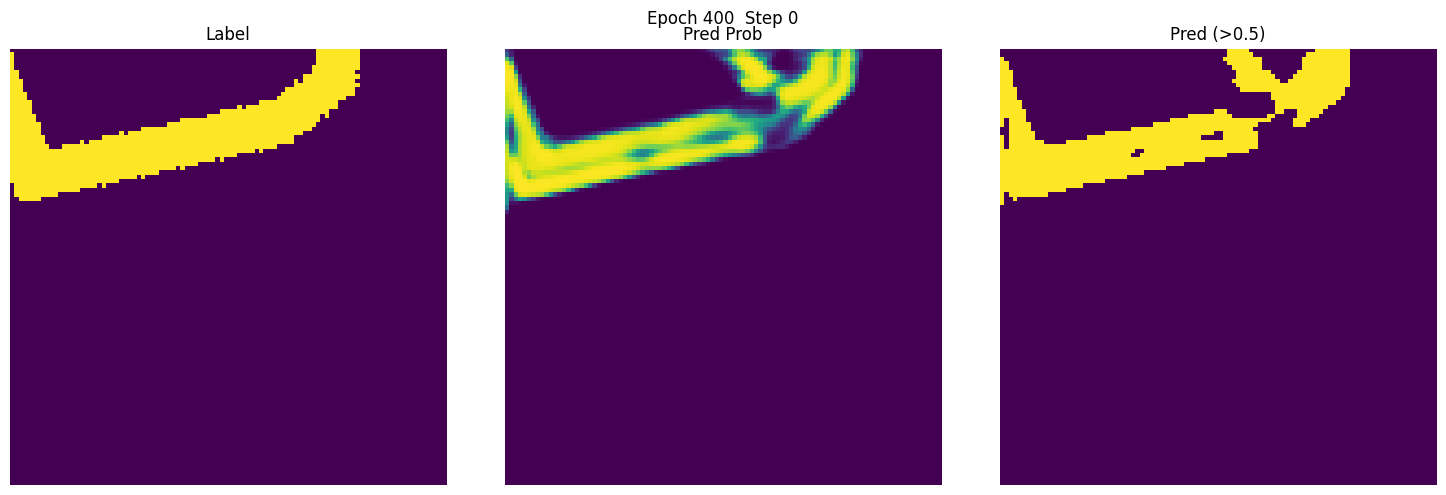

Epoch 600/2500 - loss: 0.5661
lr: 8.293506696086654e-05


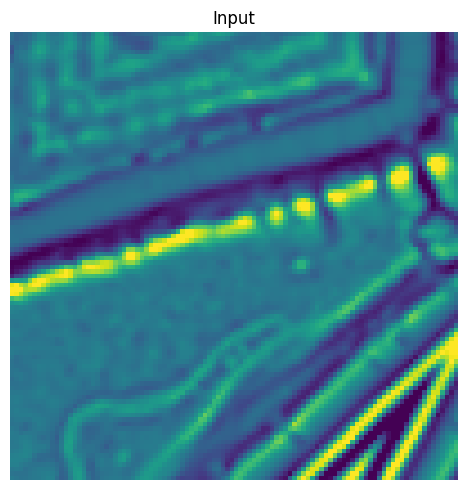

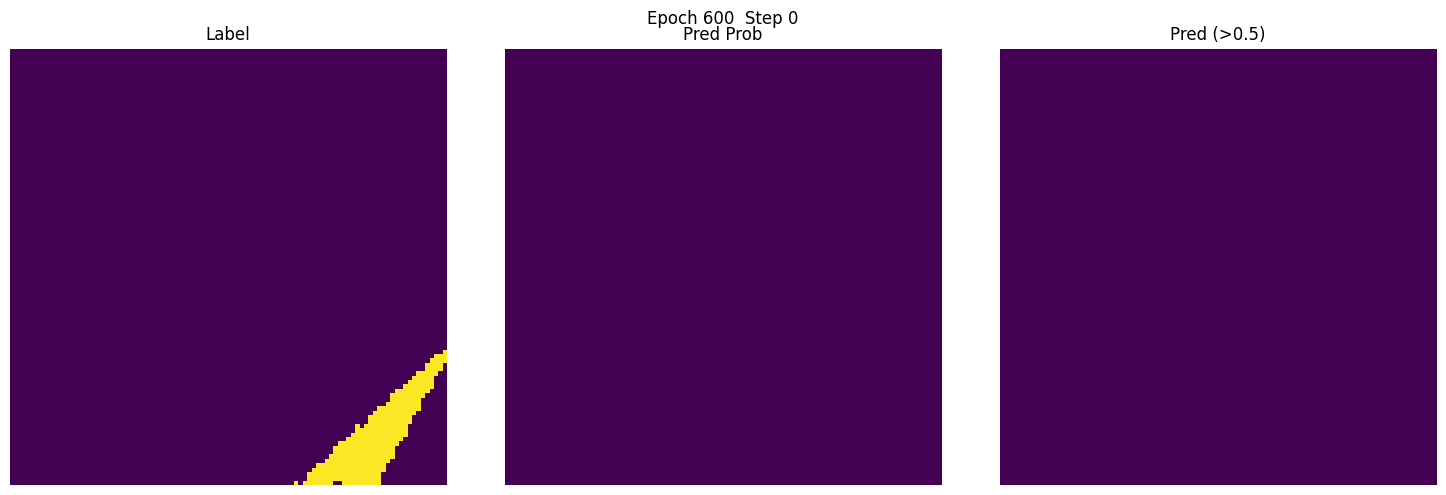

Epoch 800/2500 - loss: 0.0409
lr: 5.062993475440498e-06


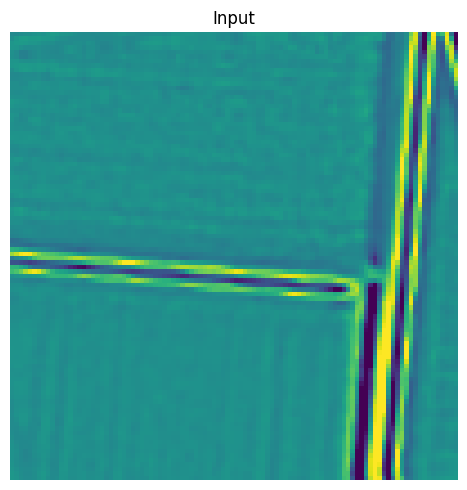

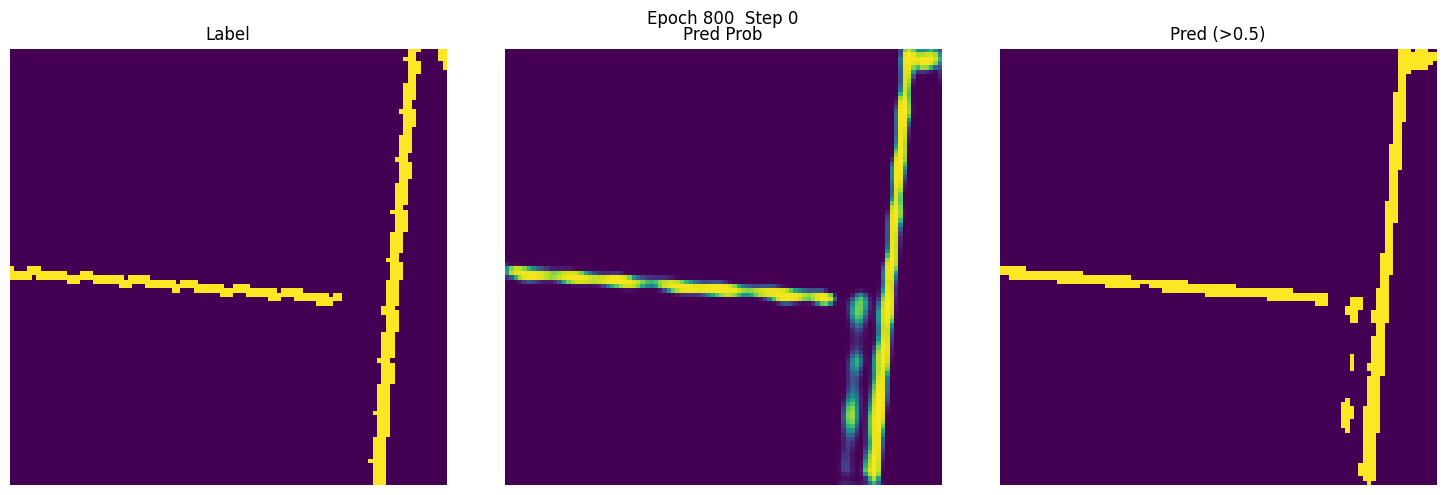

Epoch 1000/2500 - loss: 0.0243
lr: 1.402744473050793e-07


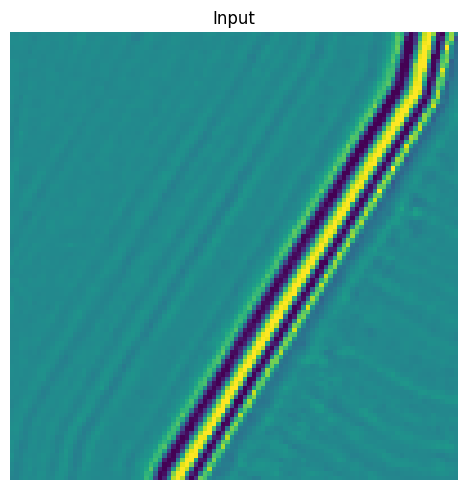

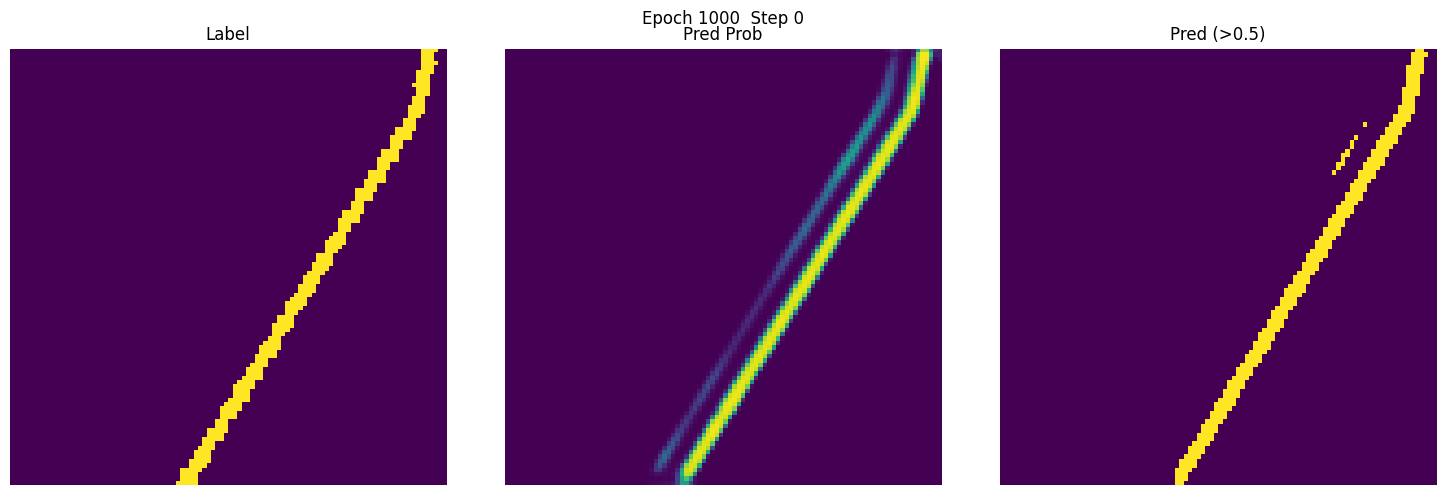

Epoch 1200/2500 - loss: 0.0120
lr: 1.7323878711141143e-09


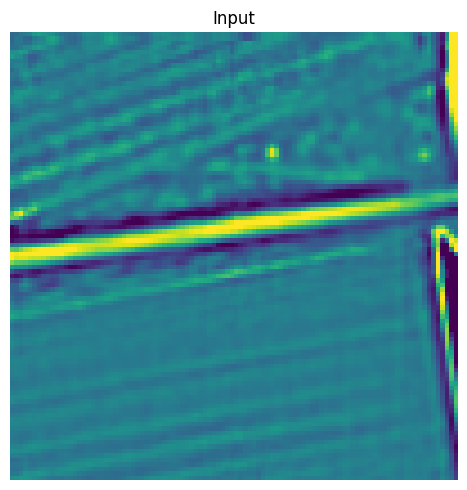

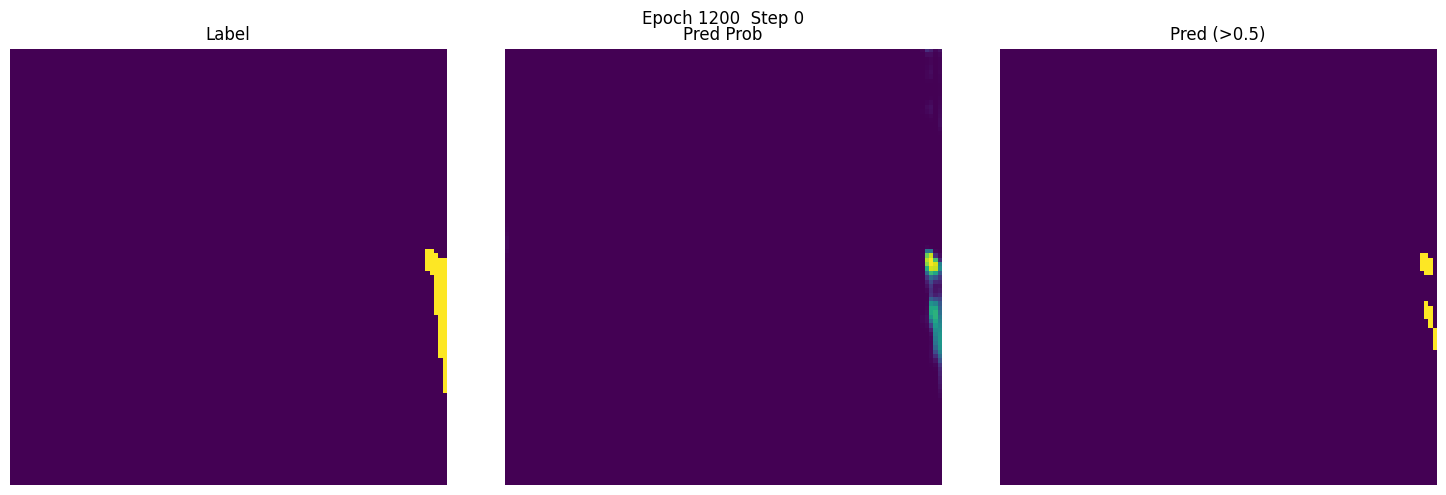

Epoch 1400/2500 - loss: 0.0271
lr: 9.613379972322722e-12


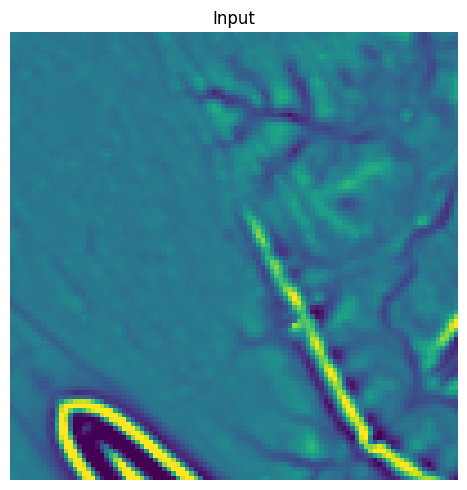

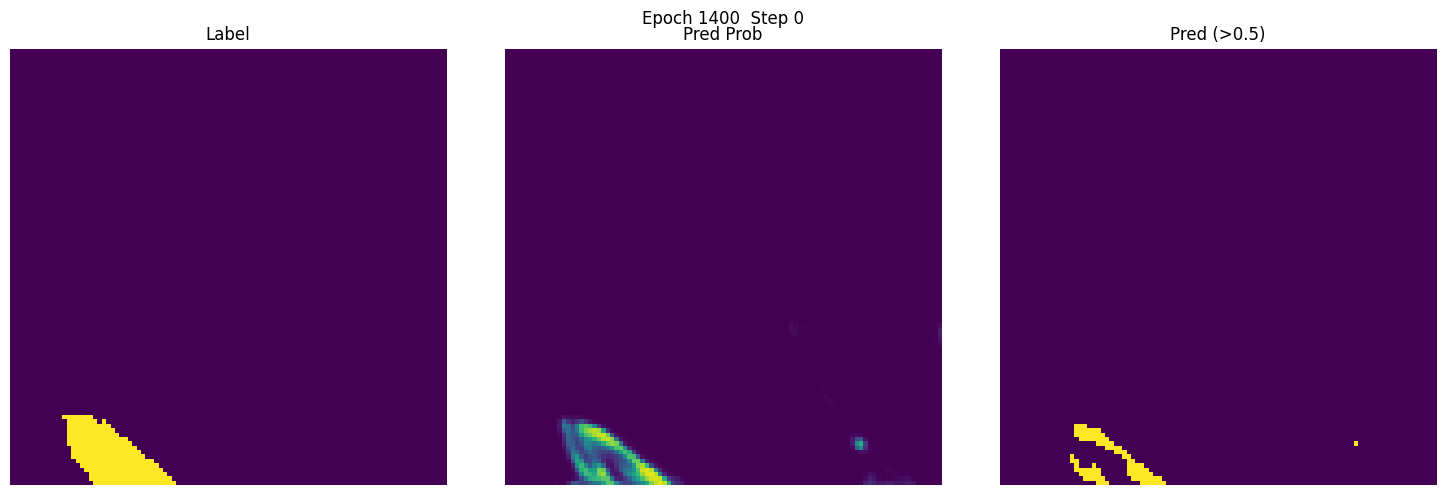

Epoch 1600/2500 - loss: 0.0000
lr: 2.3970190620033588e-14


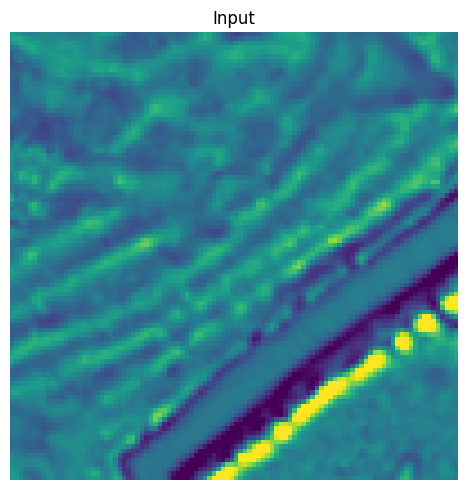

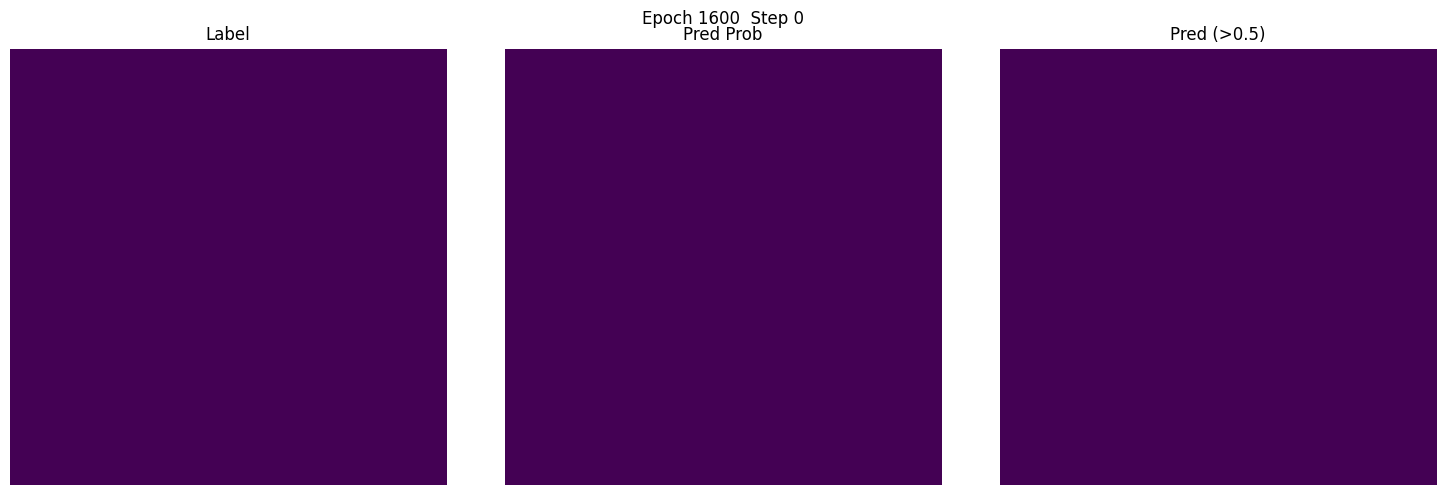

Epoch 1800/2500 - loss: 0.0160
lr: 2.685537819255037e-17


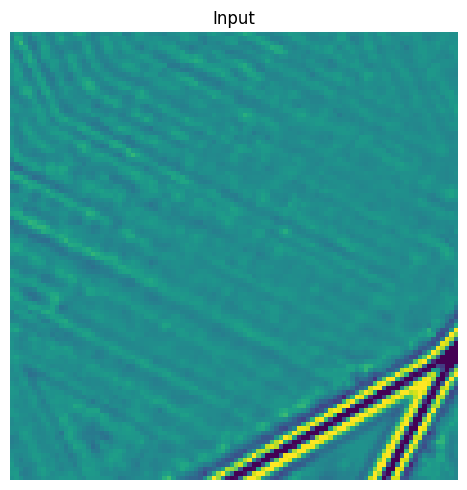

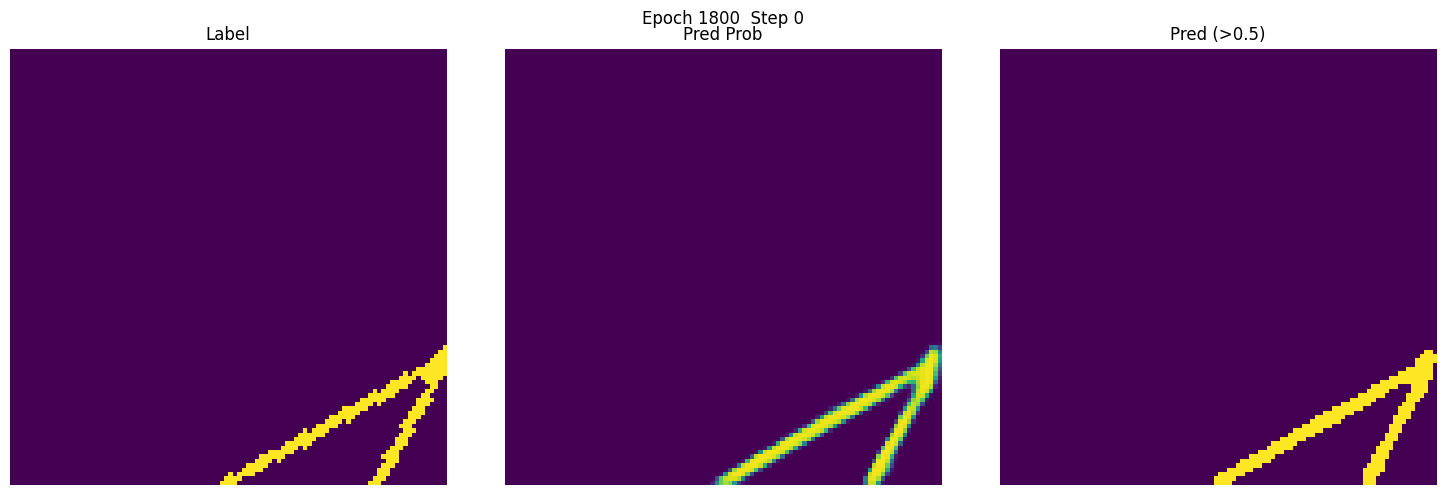

Epoch 2000/2500 - loss: 0.0000
lr: 1.3519339159906669e-20


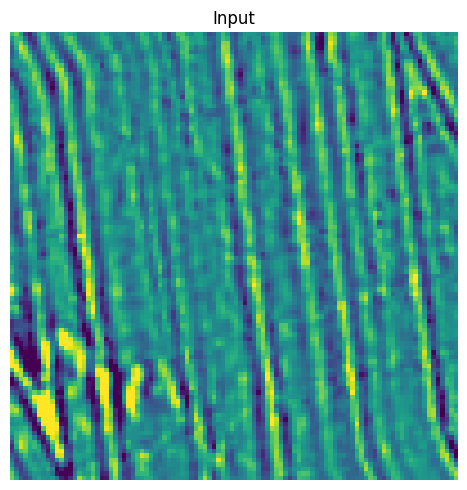

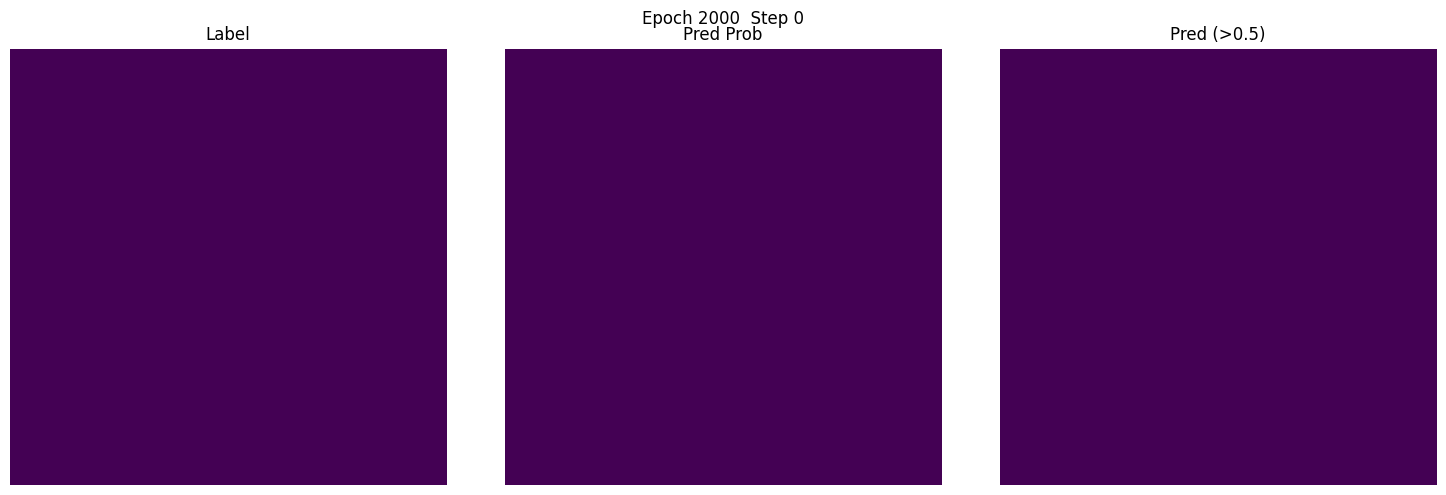

Epoch 2200/2500 - loss: 0.0274
lr: 3.0580463212125662e-24


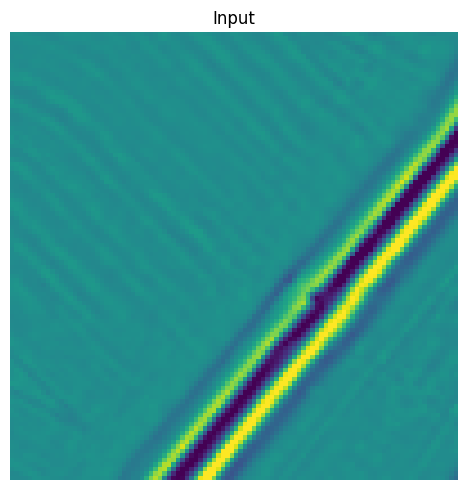

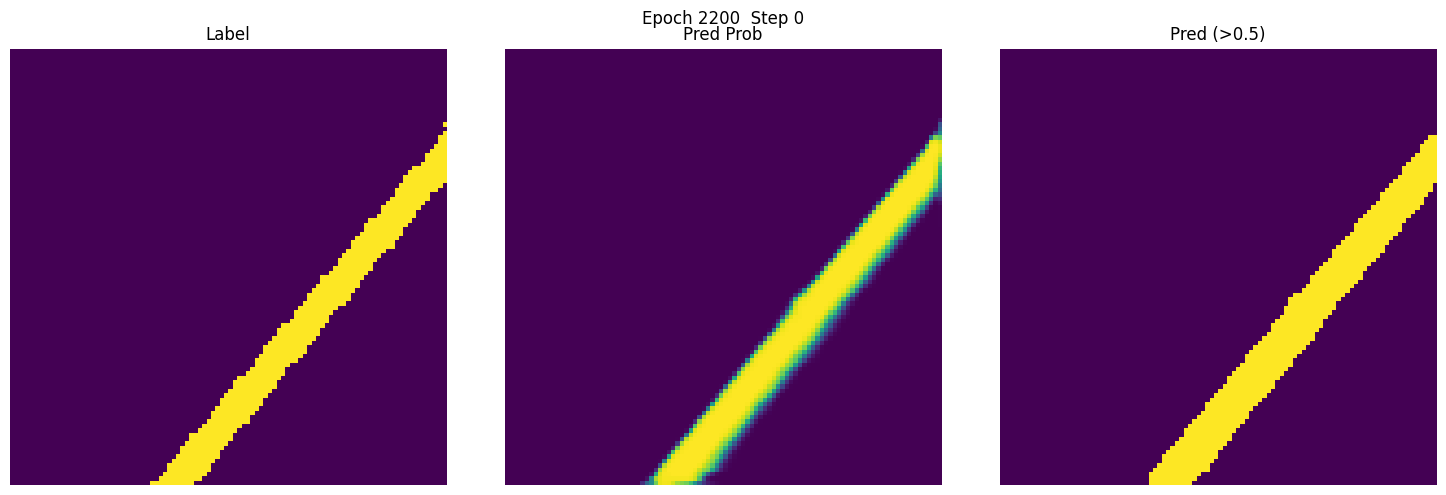

Epoch 2400/2500 - loss: 0.0069
lr: 3.108114871297139e-28


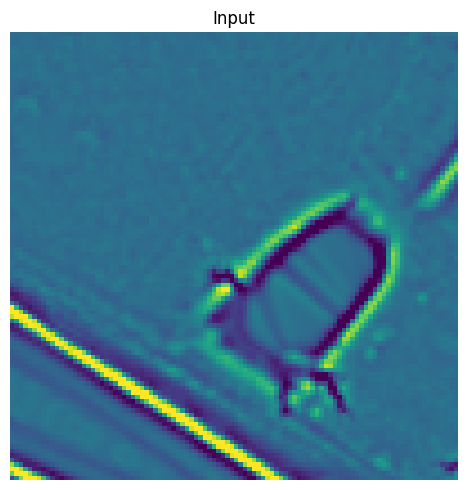

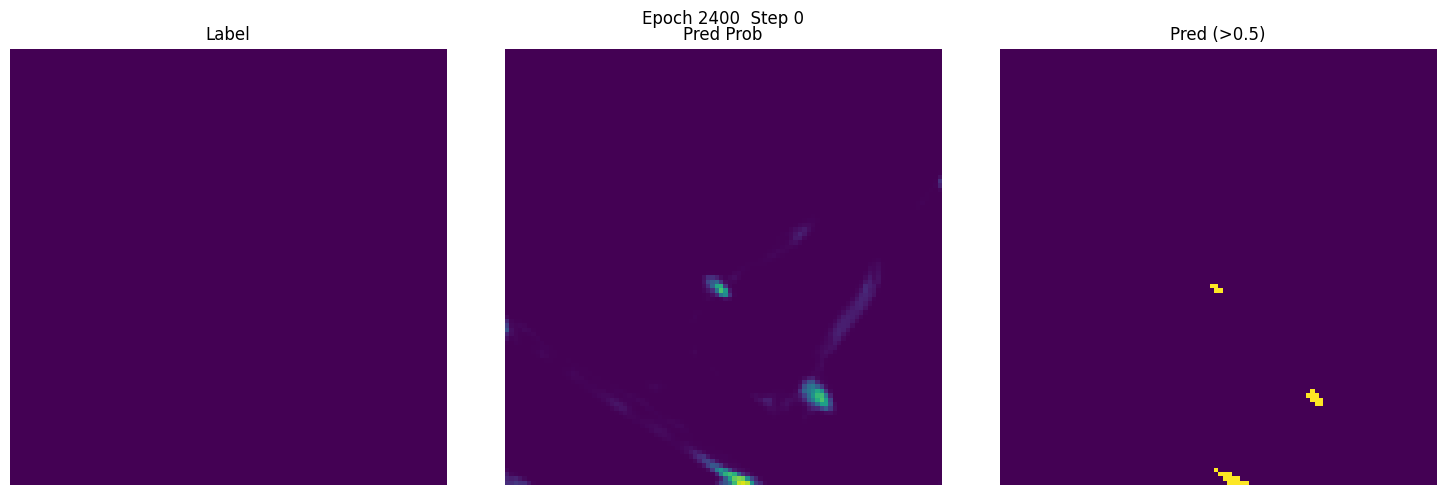


Training Complete!


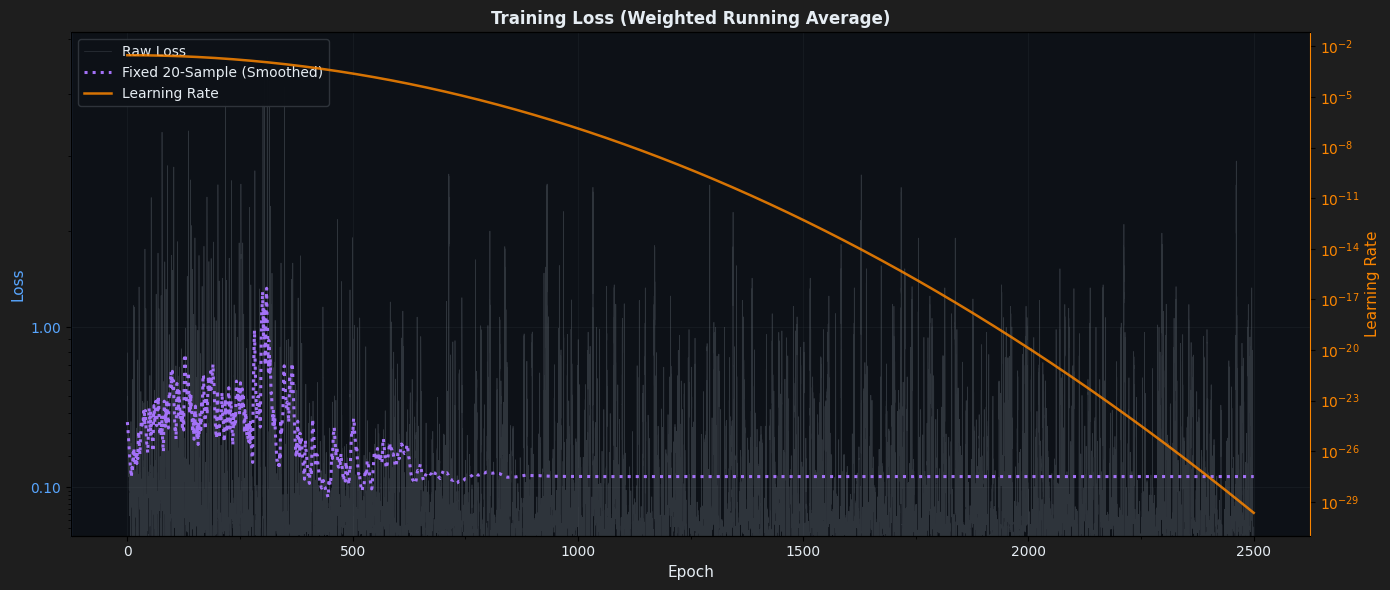


Loss Statistics:
  Final Fixed Sample Loss: 0.130275
  Initial loss: 0.792197
  Final loss: 0.020989
  Min loss: 0.000000
  Max loss: 4.642976
  Final smooth average: 0.165533
  Final responsive average: 0.037849
  Total steps: 49987


In [ ]:
# Residual connections (skip connections within block)
model_residual = train_model(willowan_data,
                    num_epochs=2500,
                    viz_every=200,
                    features=[16,32,64,128,256],
                    lr=3e-3,
                    lr_decay=0.99999995,
                    pos_bias=1,
                    block_config=UNET_BLOCK_RESIDUAL)



Training Complete!


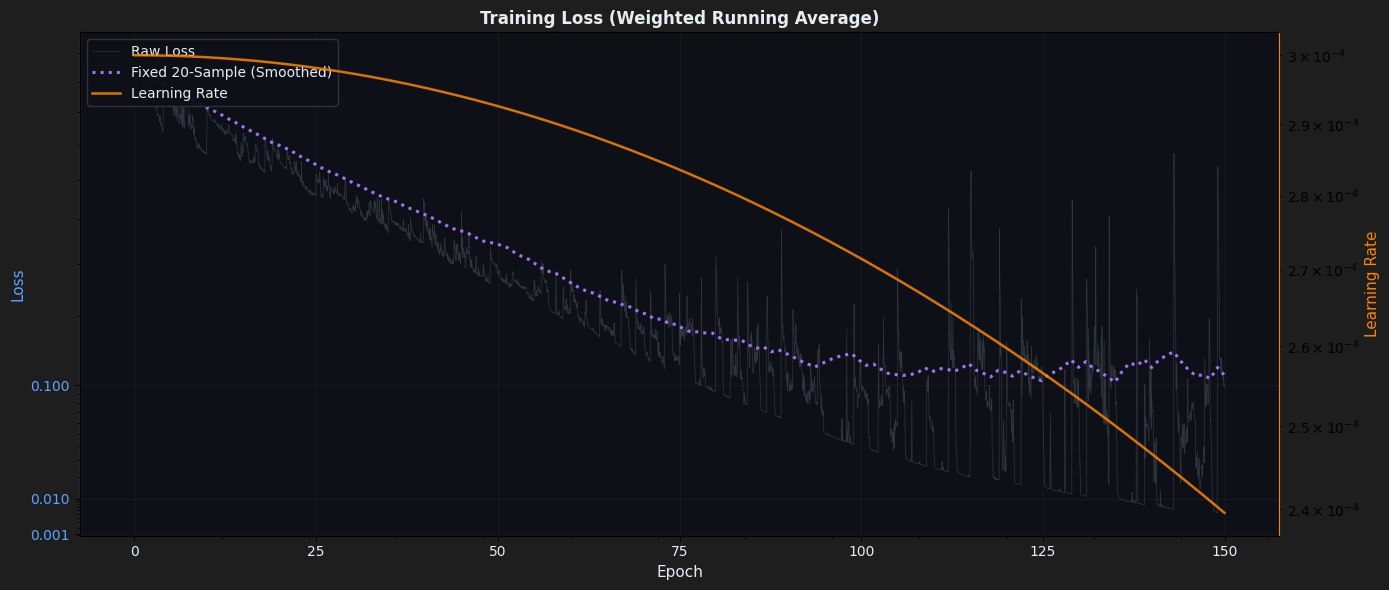


Loss Statistics:
  Final Fixed Sample Loss: 0.068691
  Initial loss: 0.855280
  Final loss: 0.096454
  Min loss: 0.005296
  Max loss: 0.892959
  Final smooth average: 0.076377
  Final responsive average: 0.120770
  Total steps: 3000


In [ ]:
# Residual connections (skip connections within block)
model_residual = train_model(willowan_data,
                    num_epochs=150,
                    viz_every=500,
                    features=[8,16,32],
                    lr=3e-4,
                    lr_decay=0.99999995,
                    pos_bias=1,
                    block_config=UNET_BLOCK_RESIDUAL)



Training Complete!


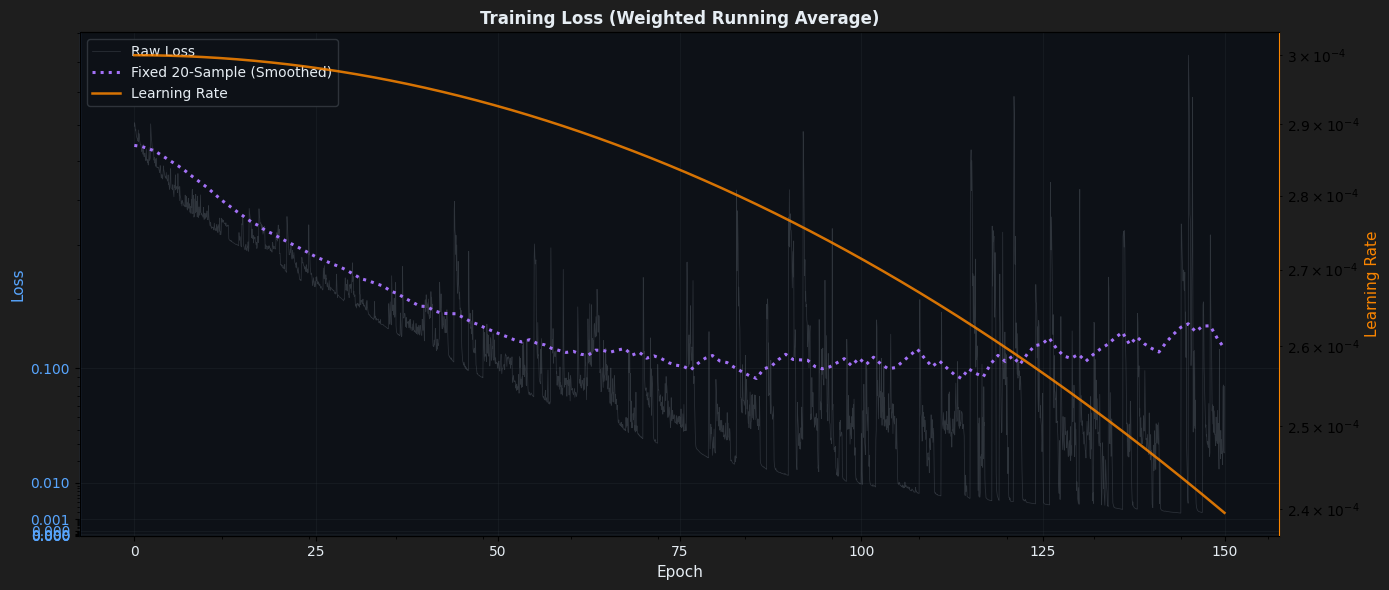


Loss Statistics:
  Final Fixed Sample Loss: 0.068827
  Initial loss: 0.596120
  Final loss: 0.079439
  Min loss: 0.001843
  Max loss: 0.821341
  Final smooth average: 0.068563
  Final responsive average: 0.049387
  Total steps: 3000


In [ ]:
# Residual connections (skip connections within block)
model_residual = train_model(willowan_data,
                    num_epochs=150,
                    viz_every=500,
                    features=[8,16,32],
                    lr=3e-4,
                    lr_decay=0.99999995,
                    pos_bias=1,
                    block_config=UNET_BLOCK_RESIDUAL)


Epoch 30/300 - loss: 0.3280
lr: 0.0002994949555890814


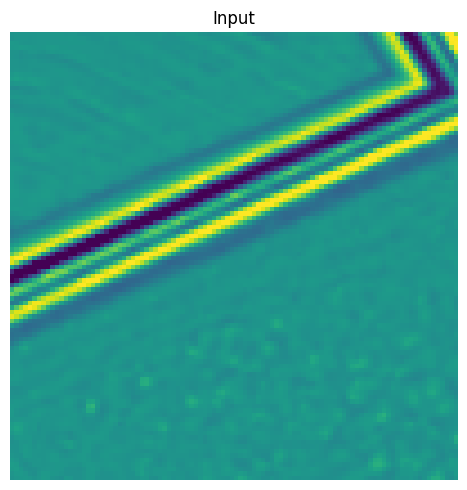

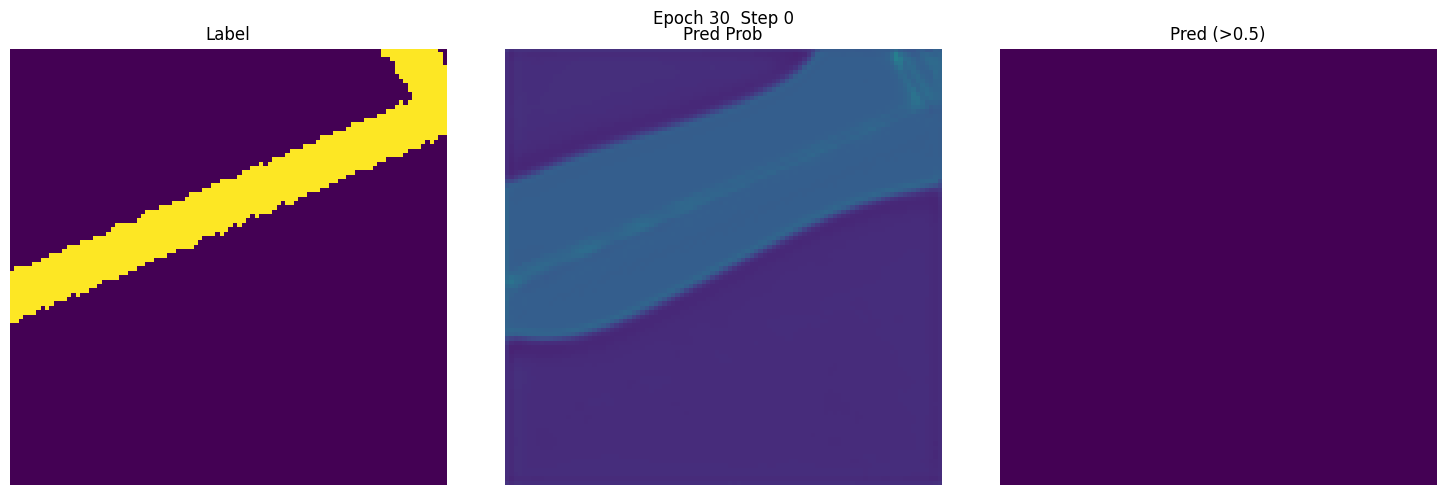

Epoch 60/300 - loss: 0.1089
lr: 0.00029791689583803083


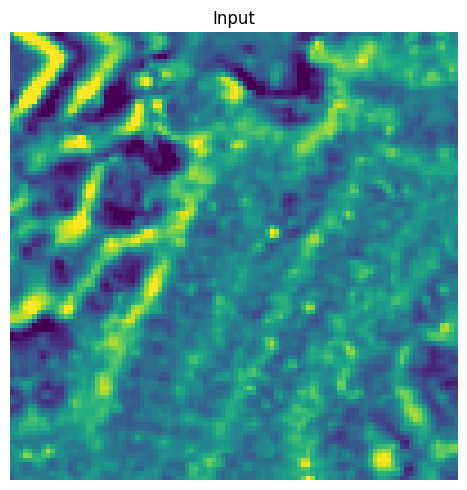

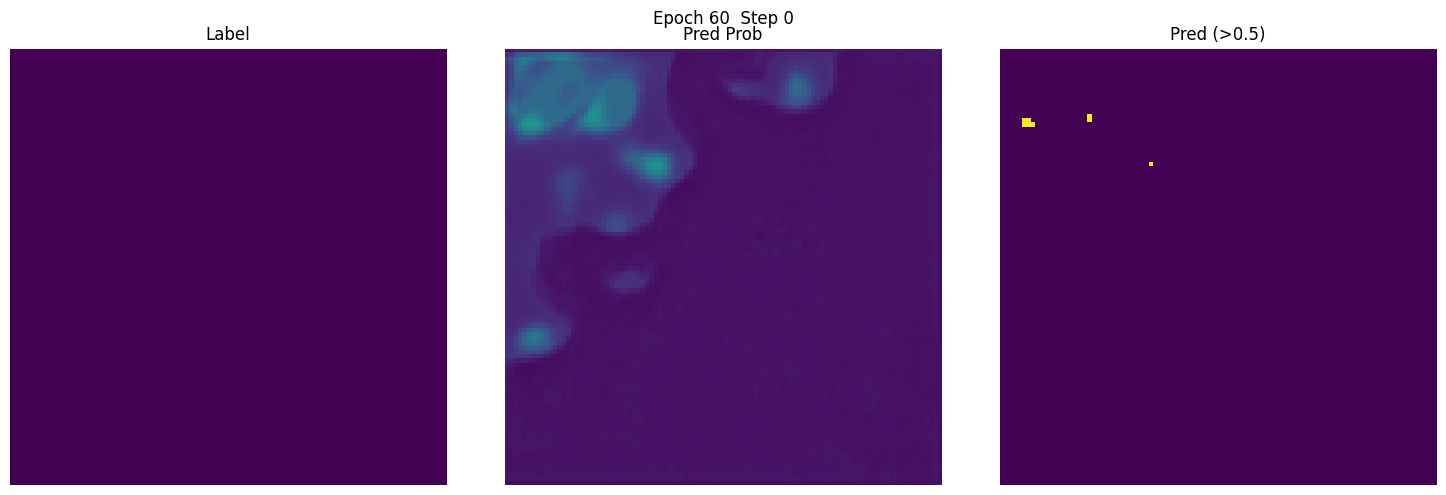

Epoch 90/300 - loss: 0.0330
lr: 0.00029528221926654574


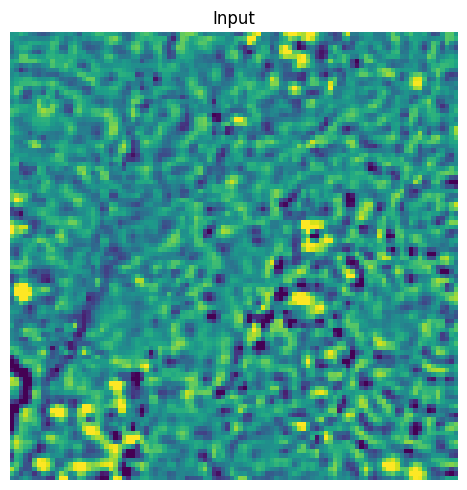

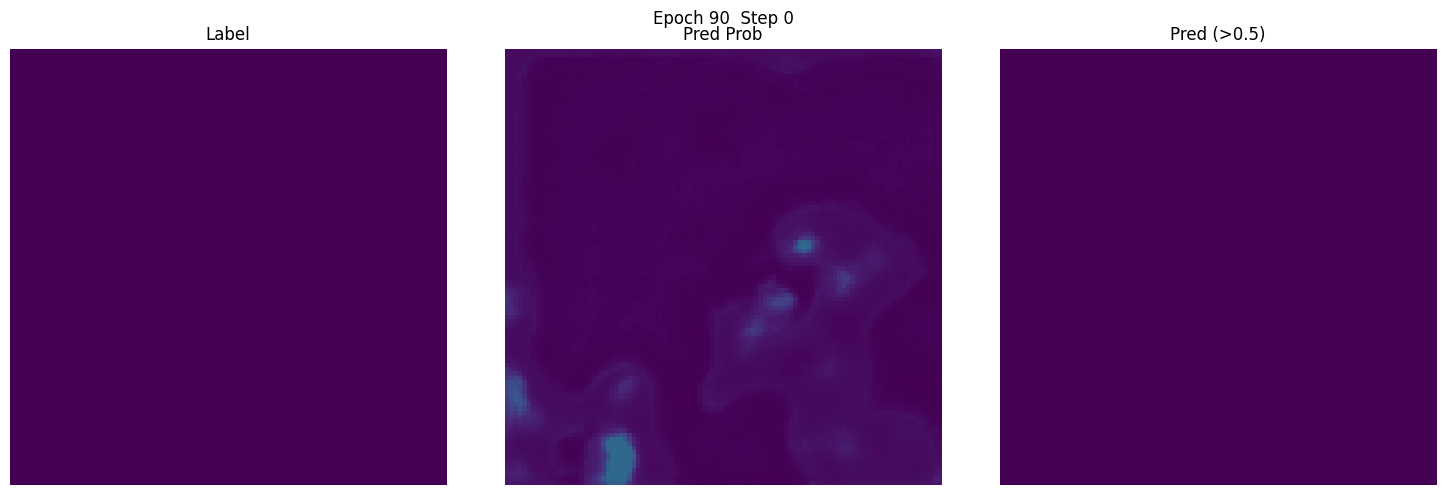

Epoch 120/300 - loss: 0.0381
lr: 0.0002916191220746514


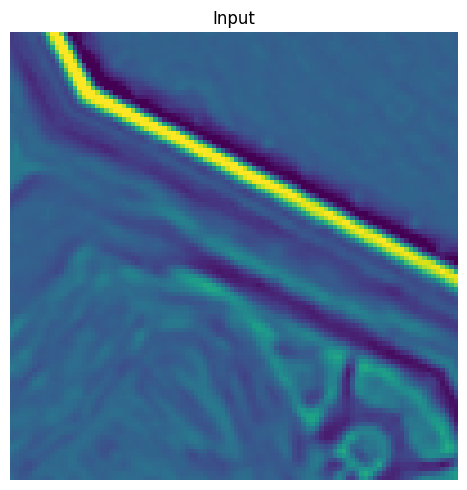

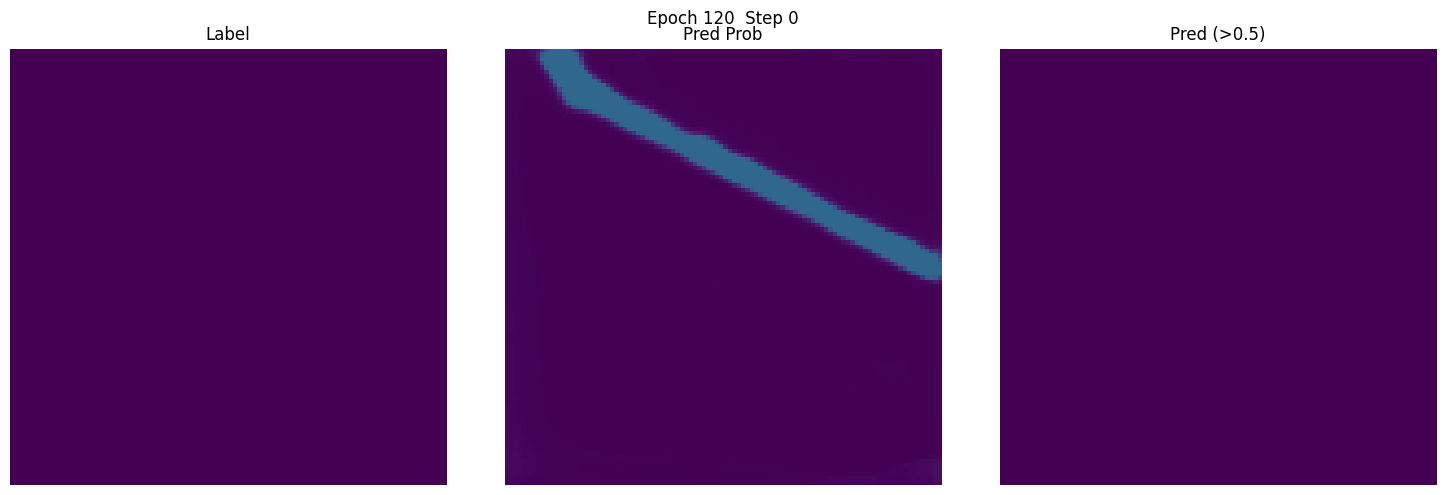

Epoch 150/300 - loss: 0.0159
lr: 0.00028696652582780414


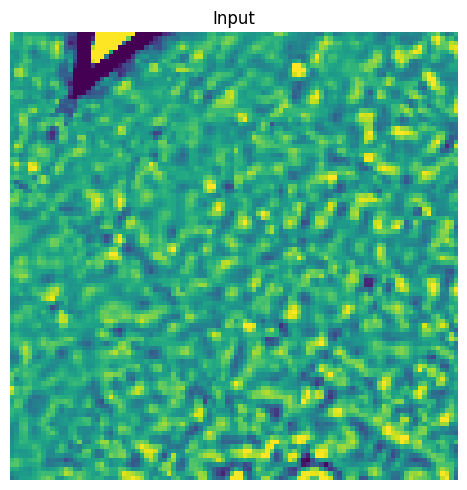

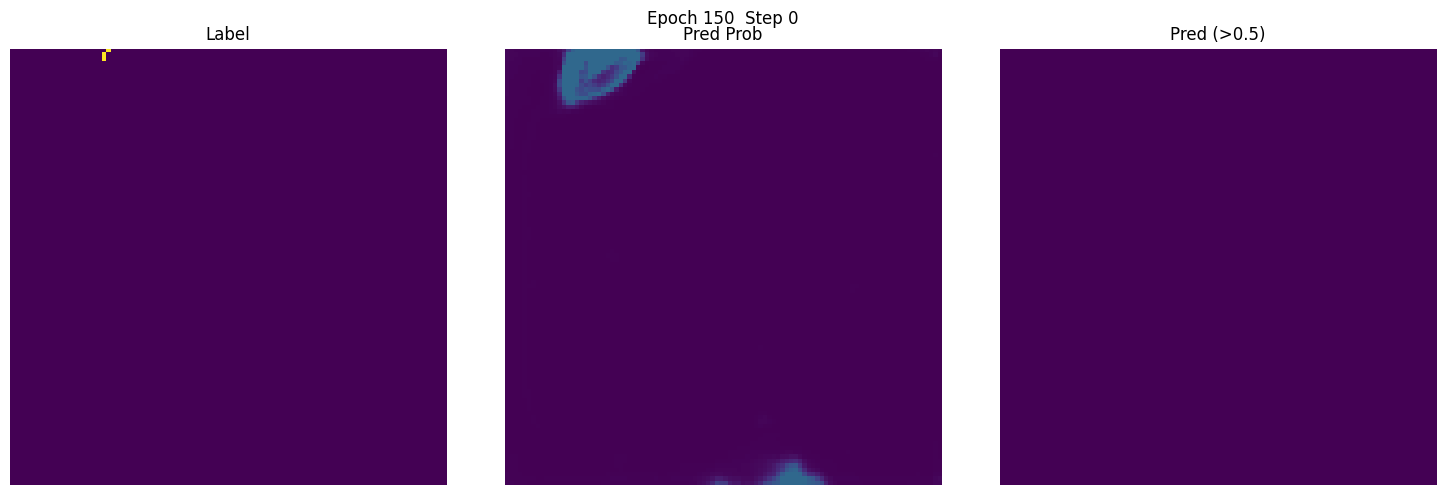

Epoch 180/300 - loss: 0.3418
lr: 0.00028137338907272447


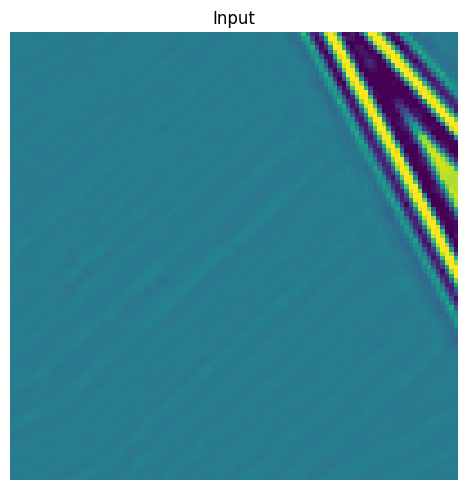

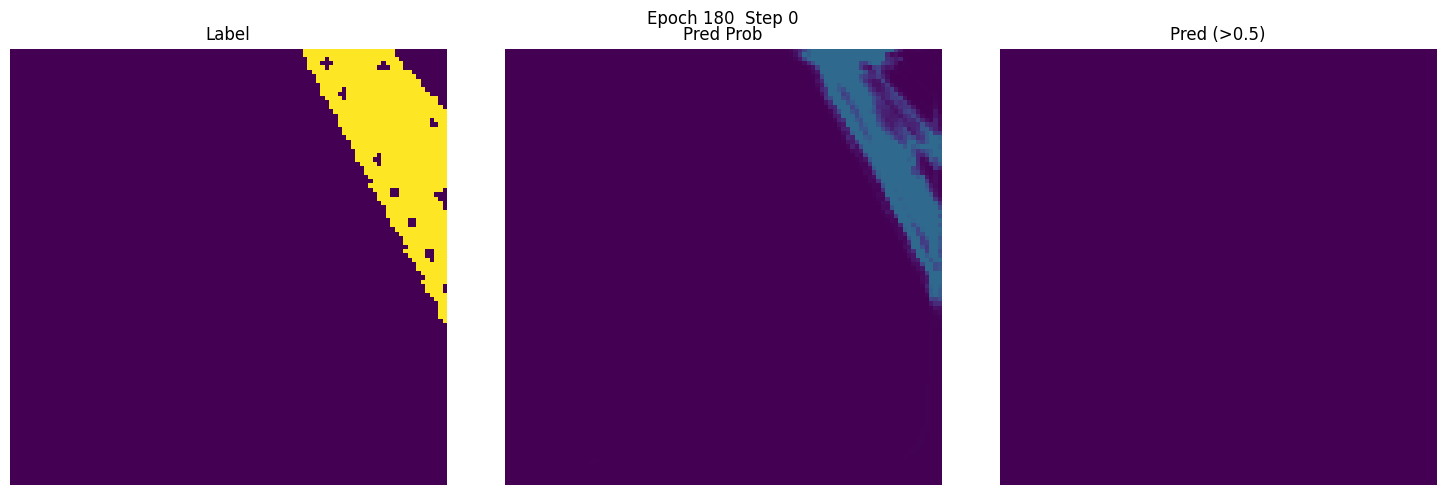

Epoch 210/300 - loss: 0.0786
lr: 0.000274897849908025


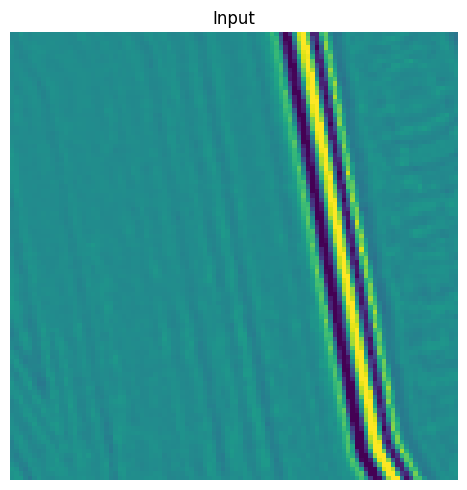

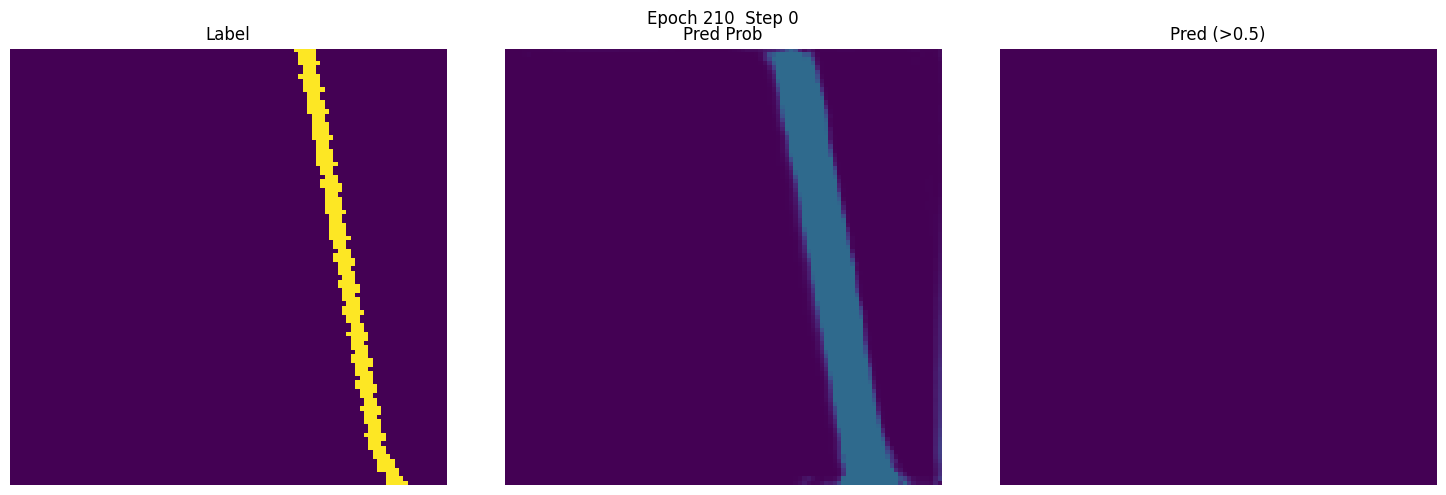

Epoch 240/300 - loss: 0.0372
lr: 0.0002676062205029754


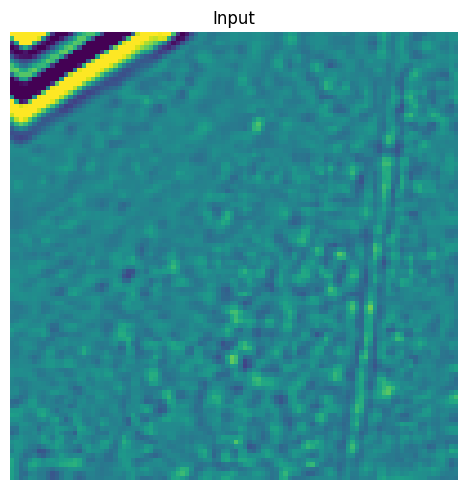

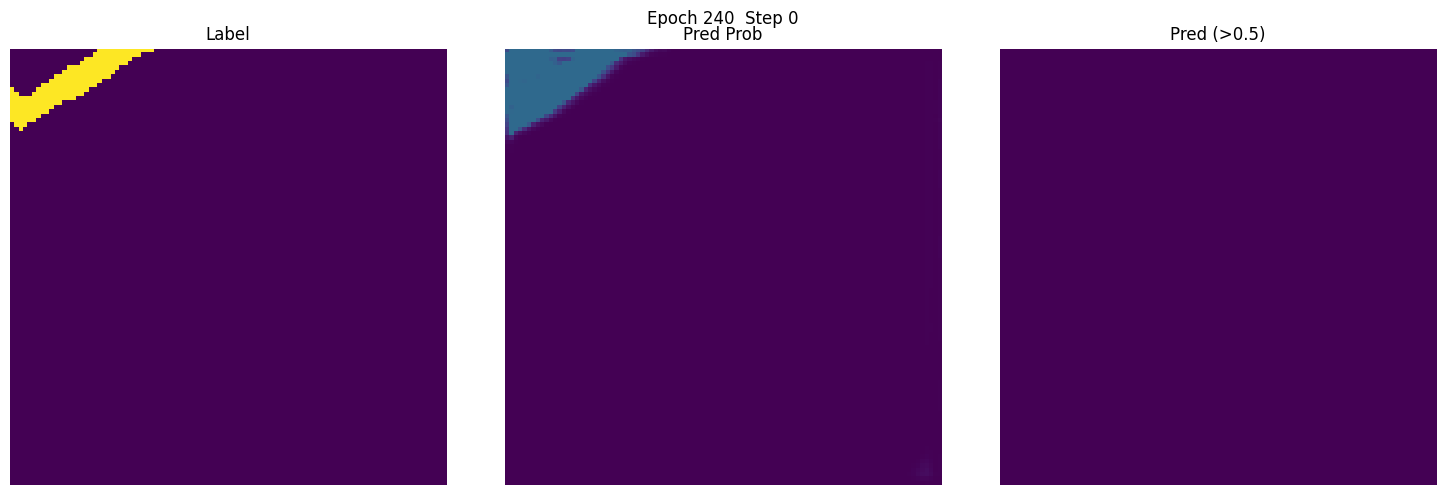

Epoch 270/300 - loss: 0.0000
lr: 0.00025957185786769593


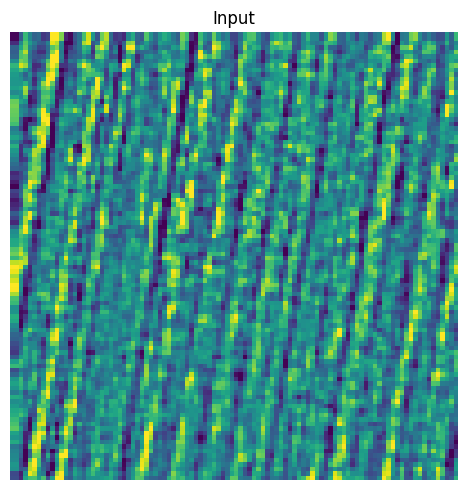

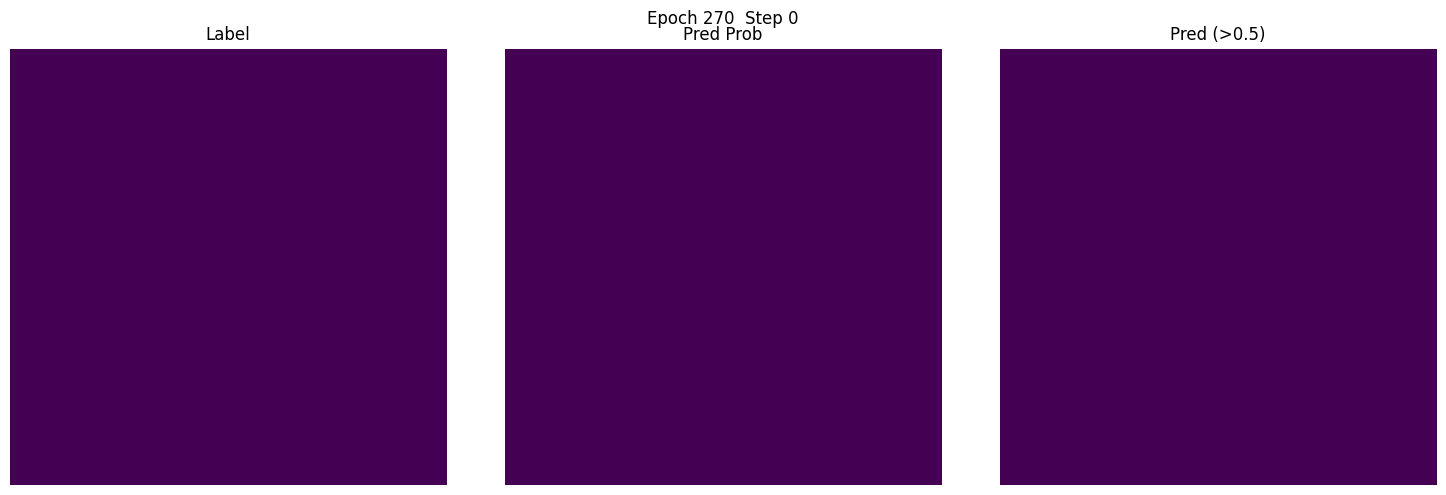

Epoch 300/300 - loss: 0.3053
lr: 0.00025087393773401645


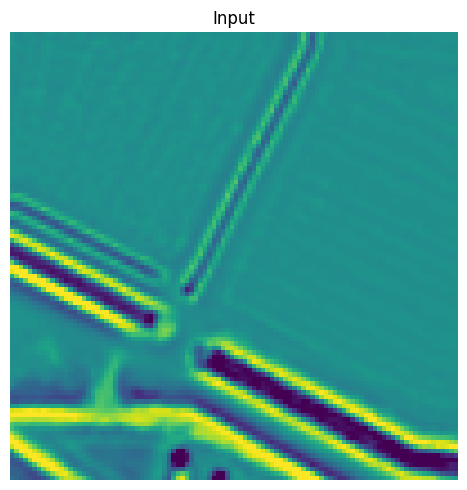

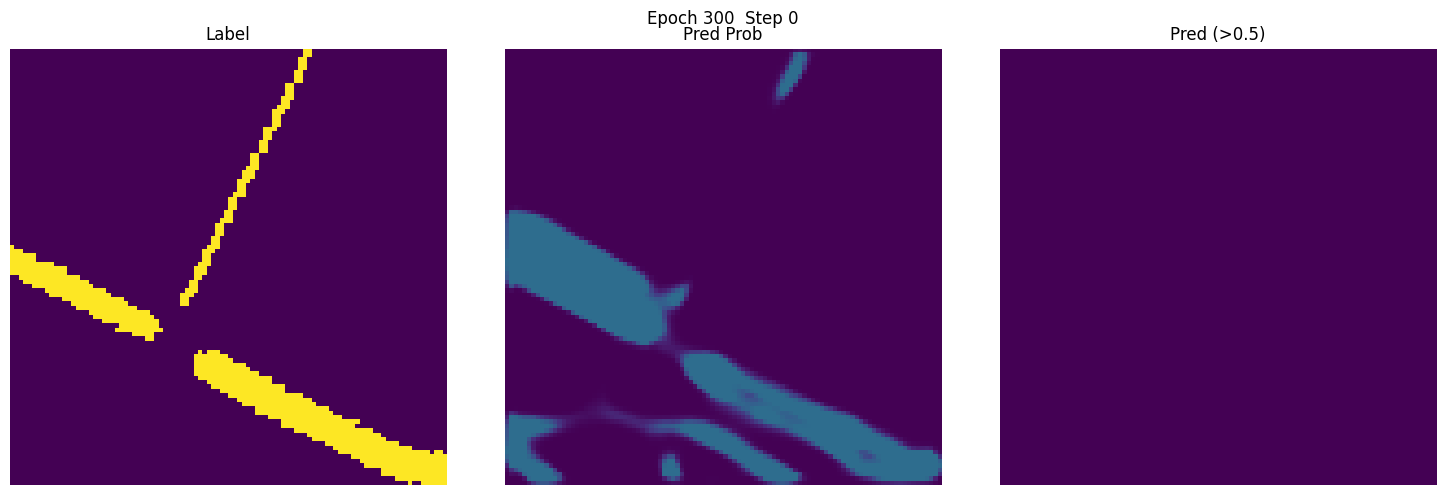


Training Complete!


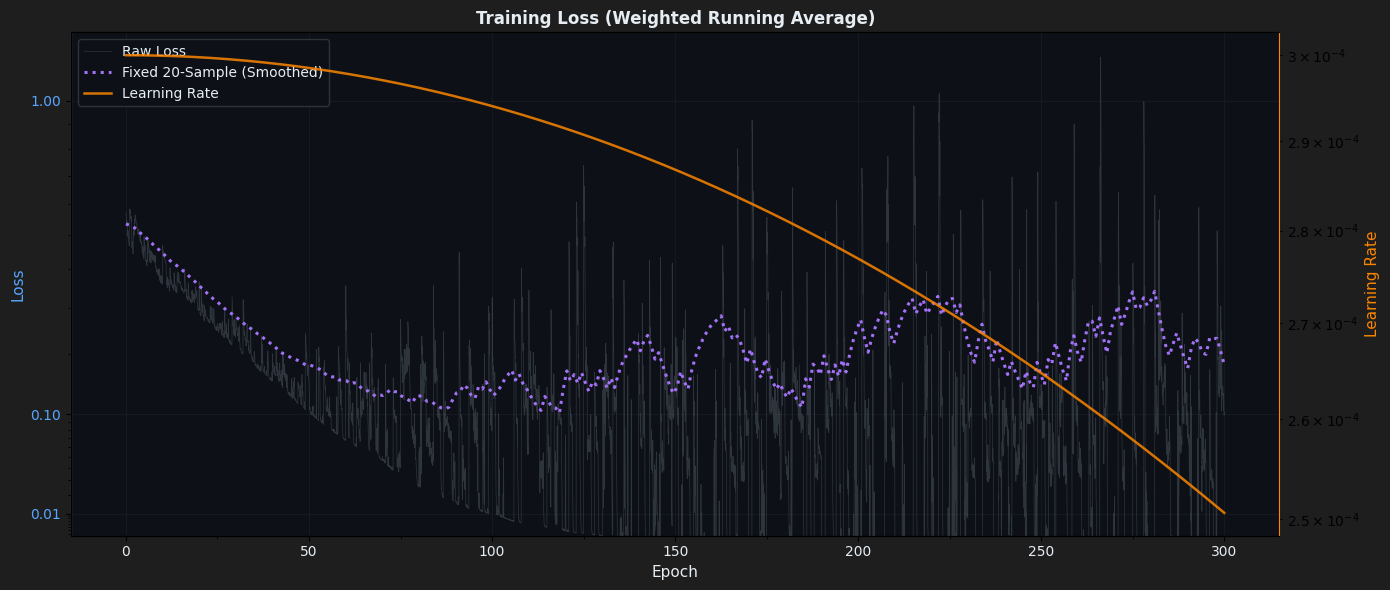


Loss Statistics:
  Final Fixed Sample Loss: 0.073178
  Initial loss: 0.571713
  Final loss: 0.102472
  Min loss: 0.000009
  Max loss: 1.199109
  Final smooth average: 0.088704
  Final responsive average: 0.139656
  Total steps: 6000


In [ ]:
# Residual connections (skip connections within block)
model_residual = train_model(willowan_data,
                    num_epochs=300,
                    viz_every=30,
                    features=[8,16,32],
                    lr=3e-4,
                    lr_decay=0.99999999,
                    pos_bias=1,
                    block_config=UNET_BLOCK_RESIDUAL)


# UNet Block Configuration Variants

Try different block architectures by passing them to train_model:


In [ ]:
dont run past here

In [ ]:
import torch
model_path ="C:\\Users\\jamed\\Documents\\repos\\terrain_classification_project\\QuickTerrainClassification\\data\\model.pth"

In [ ]:
# Create sample input with same shape as training data
sample_input = torch.randn(1, 1, 1000, 1000).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
model_residual.eval()
scripted = torch.jit.trace(model_residual, sample_input)
scripted.save(model_path)